# Film RS-FFF checkpoint diagnostics

This notebook evaluates a **film-model** checkpoint (`docs/fff_film.md`, `src/ff/film/`). Point
`CHECKPOINT` at a run directory and every figure regenerates; the model is rebuilt from the
config the checkpoint carries, so there is nothing to keep in sync by hand. It is the film port
of `eda_rsff_plotting.ipynb` (which stays pointed at the v4 fragment-expert model).

The model in one paragraph. One shared set of geometric primitives is projected through the
atom-to-fragment assignment `C` into internal, environment and cross feature blocks *before*
any nonlinear contraction; a FiLM-conditioned trunk turns them into the parameters of physical
force-field terms, each at two evaluations -- `theta_0` from the internal block alone and
`theta` with the (zero-initialized, bias-free) environment and cross embedders live. The bonded
one-body PES is a **Morse bond + cosine angle** whose parameters the network generates around
learnable per-type tables initialized at pyCMM water; the permanent multipoles are direct heads
on the internal features only (no frozen SQE solve), and the polarization response is solved
*around* them, so an isolated fragment's induction is exactly zero by construction.

The figures cover:

- correlation plots for each fitted energy component, monomer deformation energy, and total
  binding energy
- the per-fragment one-body residual, which is where a size-dependent offset in the deformation
  and binding panels would actually live
- **the isolated/environment split of every channel**, including the share of induction carried
  by the bonded-parameter shift (the learned analogue of pyCMM's field-dependent Morse)
- molecular polarizability, dipole, and quadrupole moment correlations on the monomer anchor
- **the generated parameters at both evaluations**. Static per-element tables (`r0`,
  penetration `Z`/`b`, damping exponents) are deliberately *not* plotted -- they are single
  numbers, not distributions. What is plotted is everything that genuinely varies: the
  permanent multipoles, the response parameters (`eta`, atomic `alpha`, SQE compliance), the
  Pauli/dispersion parameters, and the **bonded Morse/angle parameters** with their pyCMM
  starting values drawn as reference lines -- `theta_0` dashed against `theta` filled, so the
  gap *is* the environment dependence.
- predicted many-body contributions for each energy term
- force correlation for the total-energy gradient


In [19]:
%matplotlib inline

import os
import sys
from contextlib import contextmanager
from pathlib import Path
from types import SimpleNamespace

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import torch

# Resolve the repository root no matter where Jupyter starts the kernel.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
for p in (ROOT / "src", ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from rsfff.ff.film.bonded import DEFAULT_ANGLE_PRIOR, DEFAULT_BOND_PRIOR
from rsfff.ff.many_body import mbe_dataset
from rsfff.ff.molecular_multipoles import fragment_multipoles, reference_multipoles
from rsfff.ff.multipole import spherical_to_cartesian_quadrupole
from rsfff.ff.pairs import intra_fragment_channels
from rsfff.ff.units import BOHR_ANG, KJMOL_PER_HARTREE
from rsfff.mlip.heads import env_parameters
from rsfff.train.build_film import build_film_model
from rsfff.train.config import load_config
from rsfff.train.data import load_extxyz, load_reference_energies
from rsfff.train.loss import compute_forces
from rsfff.train.train_eem import resolve_device


In [20]:
# ---- Regeneration knobs ---------------------------------------------------------------
CHECKPOINT = "checkpoints/water_film_full/best.pt"
# Only a fallback: a checkpoint embeds the full config it was trained under, stage
# overrides already applied, and that is what gets used. Reading a YAML instead let the
# notebook build a *different* model than the weights came from, and the failure looked
# like a bad fit rather than a mismatch.
CONFIG = "configs/water_film.yaml"
DEVICE = "cpu"                  # CPU is stable for float64 plots; use "auto" if desired.
EVAL_SPLIT = "all"              # "all" or "validation"; validation is per-file here.
MAX_FRAMES_PER_CLUSTER = None    # e.g. 200 for quick iteration
BATCH_SIZE = 64
FORCE_FRAMES_PER_CLUSTER = 40    # forces need autograd; keep this modest for interactivity.
PARAMETER_FRAMES_PER_CLUSTER = 120
MBE_PER_CLUSTER = 40             # strongest frames per w3/w4/w5 cluster for MBE plots.
MBE_SORT_KEY = "int"
ISOLATED_SPECIES_REFERENCE = "data/isolated_species_wb97mv.extxyz"
REFERENCE_SPECIES = "H2O"
FIGDIR = Path("notebooks/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)
# Figure names follow the checkpoint directory, so re-running this on another stage
# writes beside the old figures instead of over them.
FIGPREFIX = Path(CHECKPOINT).parent.name

# (channel, eda components summed to make its label, plot title). The label is a *tuple*
# because `induction` is fitted against `eda_pol + eda_ct` -- polarization and charge transfer
# are one term, so no single `eda_*` column supervises it. `_TARGETS` and
# `_INDUCTION_COMPONENTS` in rsfff.train.train_film are what this mirrors.
ENERGY_TERMS = [
    ("onebody", ("fragment_energy",), "monomer deformation energy"),
    ("elst", ("cls_elec",), "frozen electrostatics"),
    ("pauli", ("mod_pauli",), "Pauli repulsion"),
    ("disp", ("disp",), "dispersion"),
    ("induction", ("pol", "ct"), "induction (pol + CT)"),
    ("total", ("energy",), "binding energy"),
]

PALETTE = {
    "w2": "#276ef1",
    "w3": "#1b998b",
    "w4": "#db6d00",
    "w5": "#7a4cc2",
}
ELEMENT = {1: "H", 8: "O"}
ELEMENT_COLOR = {1: "#276ef1", 8: "#d64545"}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e8ef",
    "grid.linewidth": 0.7,
    "axes.labelcolor": "#20242c",
    "axes.edgecolor": "#aeb4c0",
    "xtick.color": "#3c4450",
    "ytick.color": "#3c4450",
    "font.size": 9,
})


In [21]:
def torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def stage_of(cfg):
    """Which stage this checkpoint's run directory belongs to, or None for a single fit."""
    for stage in cfg.stages:
        if cfg.run_name.endswith(f"_{stage.name}"):
            return stage.name
    return None


def load_film_checkpoint(checkpoint=CHECKPOINT, device=DEVICE, config_fallback=CONFIG):
    """Rebuild the film model from the checkpoint's **own** embedded config.

    A checkpoint stores the full `Config` it was trained under, stage overrides already applied,
    so nothing here reads a YAML and there is no stage to infer. `config_fallback` is only used
    for a checkpoint too old to carry one.

    `strict=True` on purpose -- a missing or unexpected tensor means the code has moved since
    the checkpoint was written, and loading anyway would plot a partly-initialized model.
    """
    state = torch_load(checkpoint)
    cfg = state.get("config")
    if cfg is None:
        cfg = load_config(config_fallback)
    torch.set_default_dtype(torch.float64 if cfg.dtype == "float64" else torch.float32)

    neighbor_types = tuple(int(z) for z in state["neighbor_types"])
    reference_energies = load_reference_energies(
        cfg.data.reference_energies, neighbor_types
    ).to(torch.get_default_dtype())
    model = build_film_model(cfg.features, cfg.film, neighbor_types, reference_energies)
    model.load_state_dict(state["model_state"], strict=True)
    model.eval()
    resolved = torch.device("cpu" if device == "cpu" else resolve_device(device, cfg.dtype))
    model.to(resolved)
    return model, cfg, state, stage_of(cfg), resolved


@contextmanager
def environment_off(model):
    """Make every parameter come out at `theta_0` for the duration of the block.

    Two switches, and the film model needs both:

    1. zero the environment/cross **embedder weights** (`env_parameters` names exactly those
       two matrices) -- the joined trunk latent then equals the isolated one bitwise, which
       silences every head that reads `z_joined`: eta, alpha, compliance, Pauli, dispersion;
    2. suppress the bonded-delta **gate** (`gate_a0 -> inf`, so `g(a_env) = 0` exactly) -- the
       bonded head's env branch is `g * delta(z_joined)`, and with only the embedders zeroed
       `delta(z_iso)` would still leak through a live gate.

    Inside the block the model answers with `theta_0` everywhere. It is also a live check of
    the model's central claim: `fragment_energy` and the permanent multipoles must come out
    **bitwise identical** either way, because no environment path reaches them.
    `collect_isolated_vs_env` asserts exactly that rather than trusting it.
    """
    saved = [(p, p.detach().clone()) for _name, p in env_parameters(model)]
    saved_a0 = model.network.gate_a0
    try:
        with torch.no_grad():
            for p, _ in saved:
                p.zero_()
        model.network.gate_a0 = float("inf")
        yield model
    finally:
        model.network.gate_a0 = saved_a0
        with torch.no_grad():
            for p, original in saved:
                p.copy_(original)


def cluster_tag(path):
    name = Path(path).name
    for token in name.replace("-", "_").split("_"):
        if token.startswith("w") and token[1:].isdigit():
            return token
    return Path(path).stem


def load_cluster_datasets(cfg):
    paths = cfg.data.path if isinstance(cfg.data.path, list) else [cfg.data.path]
    dtype = torch.float64 if cfg.dtype == "float64" else torch.float32
    return {cluster_tag(p): load_extxyz(p, dtype=dtype) for p in paths}


def reference_species_energy(path=ISOLATED_SPECIES_REFERENCE, species=REFERENCE_SPECIES):
    from ase.io import iread

    for atoms in iread(str(path), index=":"):
        if atoms.info.get("name") == species:
            return float(atoms.get_potential_energy())
    raise ValueError(f"no frame named {species!r} in {path}")


def frame_indices(dataset, cfg):
    n = len(dataset)
    idx = np.arange(n)
    if EVAL_SPLIT == "validation":
        rng = np.random.default_rng(cfg.data.seed)
        perm = rng.permutation(n)
        n_val = max(1, int(round(n * cfg.data.holdout_fraction)))
        idx = np.sort(perm[:n_val])
    elif EVAL_SPLIT != "all":
        raise ValueError("EVAL_SPLIT must be 'all' or 'validation'")
    if MAX_FRAMES_PER_CLUSTER is not None:
        idx = idx[:MAX_FRAMES_PER_CLUSTER]
    return idx.tolist()


def to_np(x):
    return x.detach().cpu().numpy()


def fragment_to_system(batch):
    if batch.fragment_to_batch is not None:
        return batch.fragment_to_batch
    f2b = batch.batch_idx.new_zeros(batch.n_fragments)
    return f2b.scatter_(0, batch.fragment_idx, batch.batch_idx)


def pool_fragments_to_frames(values, batch):
    f2b = fragment_to_system(batch)
    return values.new_zeros(batch.n_systems).index_add_(0, f2b, values)


In [22]:
model, cfg, state, stage_name, device = load_film_checkpoint()
datasets = load_cluster_datasets(cfg)
anchor = load_extxyz(cfg.data.monomer_path, dtype=torch.get_default_dtype()) if cfg.data.monomer_path else None
h2o_reference_energy = reference_species_energy()

n_all = sum(p.numel() for p in model.parameters())
n_env = sum(p.numel() for _n, p in env_parameters(model))

print(f"checkpoint: {CHECKPOINT}")
print(f"stage: {stage_name or 'single'}    run_name: {cfg.run_name}")
print(f"epoch: {state.get('epoch', 'unknown')}    val_loss: {state.get('val_loss', float('nan')):.6g}")
print(f"device: {device}    dtype: {cfg.dtype}")
print(f"conditioning_mode: {cfg.film.conditioning_mode}    gate_a0: {cfg.film.gate_a0}    "
      f"induction: {model.induction}")
print(f"parameters: {n_all}, of which {n_env} in the env/cross embedders")
print(f"env_penalty_weight: {cfg.film.env_penalty_weight}    "
      f"bonded_variance_weight: {cfg.film.bonded_variance_weight}")

# Where the learnable bonded tables have moved relative to their pyCMM initialization: the
# geometry-independent part of each Morse/angle parameter, one line per (element pair | apex).
head = model.network.bonded_head
r_eq0, d0, k0 = DEFAULT_BOND_PRIOR[(1, 8)]
t0, kt0 = DEFAULT_ANGLE_PRIOR[8]
oh = head.bond_table.detach()[0, 1].exp()   # species order (H, O): [H][O] row
apex_o = head.angle_table.detach()[1]
print(f"O-H table:  r_eq {float(oh[0]):.4f} bohr (pyCMM {r_eq0:.4f})   "
      f"D {float(oh[1]):.4f} Ha (pyCMM {d0:.4f})   k {float(oh[2]):.4f} (pyCMM {k0:.4f})")
print(f"HOH table:  theta_eq {float(torch.tanh(apex_o[0]).arccos()):.4f} rad (pyCMM {t0:.4f})   "
      f"k_theta {float(apex_o[1].exp()):.4f} Ha (pyCMM {kt0:.4f})")
print(f"{REFERENCE_SPECIES} reference: {h2o_reference_energy:.12f} Ha from {ISOLATED_SPECIES_REFERENCE}")
print("datasets:", {tag: len(ds) for tag, ds in datasets.items()})
if anchor is not None:
    print(f"monomer anchor: {len(anchor)} frames from {cfg.data.monomer_path}")


checkpoint: checkpoints/water_film_full/best.pt
stage: full    run_name: water_film_full
epoch: 79    val_loss: 89.7904
device: cpu    dtype: float64
conditioning_mode: film    gate_a0: 0.5    induction: True
parameters: 479083, of which 25600 in the env/cross embedders
env_penalty_weight: 0.0    bonded_variance_weight: 0.01
O-H table:  r_eq 1.0000 bohr (pyCMM 1.8121)   D 1.0000 Ha (pyCMM 0.1997)   k 1.0000 (pyCMM 0.5438)
HOH table:  theta_eq 1.8309 rad (pyCMM 1.8225)   k_theta 0.1748 Ha (pyCMM 0.1722)
H2O reference: -76.433472976700 Ha from data/isolated_species_wb97mv.extxyz
datasets: {'w2': 2398, 'w3': 2392, 'w4': 2395, 'w5': 2394}
monomer anchor: 499 frames from data/wb97mv_tzvpd/h2o_wb97mv_tzvpd_pol.xyz


In [23]:
def fragments_per_frame(batch):
    f2b = fragment_to_system(batch)
    return torch.bincount(f2b, minlength=batch.n_systems).to(batch.positions.dtype)


def collect_energy_predictions(model, datasets, cfg, device, monomer_ref_energy, batch_size=BATCH_SIZE):
    rows = {term: {"ref": [], "pred": [], "tag": []} for term, _, _ in ENERGY_TERMS}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)

            for term, target, _label in ENERGY_TERMS:
                if term == "total":
                    n_frag = fragments_per_frame(batch)
                    pred = out.energy - monomer_ref_energy * n_frag
                    ref = batch.energy - monomer_ref_energy * n_frag
                elif term == "onebody":
                    if batch.fragment_energy is None:
                        continue
                    pred = pool_fragments_to_frames(out.fragment_energy - monomer_ref_energy, batch)
                    ref = pool_fragments_to_frames(batch.fragment_energy - monomer_ref_energy, batch)
                else:
                    # `target` is a tuple: induction's label is the sum of two EDA columns.
                    # Skip the channel unless the model has it *and* every component of its
                    # label is on the batch -- an isolated-stage checkpoint has no `induction`
                    # in `out.interaction`, which is what drops the panel rather than an error.
                    if term not in out.interaction or batch.eda is None:
                        continue
                    if any(k not in batch.eda for k in target):
                        continue
                    pred = out.interaction[term]
                    ref = sum(batch.eda[k] for k in target)
                rows[term]["pred"].append(to_np(pred) * KJMOL_PER_HARTREE)
                rows[term]["ref"].append(to_np(ref) * KJMOL_PER_HARTREE)
                rows[term]["tag"].extend([tag] * len(pred))
    packed = {}
    for term, data in rows.items():
        if data["pred"]:
            packed[term] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "tag": np.asarray(data["tag"]),
            }
    return packed


def metrics(ref, pred):
    err = pred - ref
    if len(ref) > 1 and np.std(ref) > 0 and np.std(pred) > 0:
        r2 = float(np.corrcoef(ref, pred)[0, 1] ** 2)
    else:
        r2 = np.nan
    return float(np.abs(err).mean()), float(np.sqrt(np.mean(err ** 2))), r2


energy = collect_energy_predictions(model, datasets, cfg, device, h2o_reference_energy)
print(f"{'term':<12}{'n':>8}{'MAE':>12}{'RMSE':>12}{'R2':>10}")
for term, _target, label in ENERGY_TERMS:
    if term not in energy:
        continue
    mae, rmse, r2 = metrics(energy[term]["ref"], energy[term]["pred"])
    print(f"{term:<12}{len(energy[term]['ref']):>8}{mae:>12.4f}{rmse:>12.4f}{r2:>10.5f}  {label}")


term               n         MAE        RMSE        R2
onebody         9579      0.0322      0.0588   0.99996  monomer deformation energy
elst            9579      0.7340      1.0148   0.99959  frozen electrostatics
pauli           9579      0.4783      0.6805   0.99989  Pauli repulsion
disp            9579      0.3711      0.5045   0.99829  dispersion
induction       9579      0.3939      0.5388   0.99945  induction (pol + CT)
total           9579      0.9287      1.2847   0.99675  binding energy


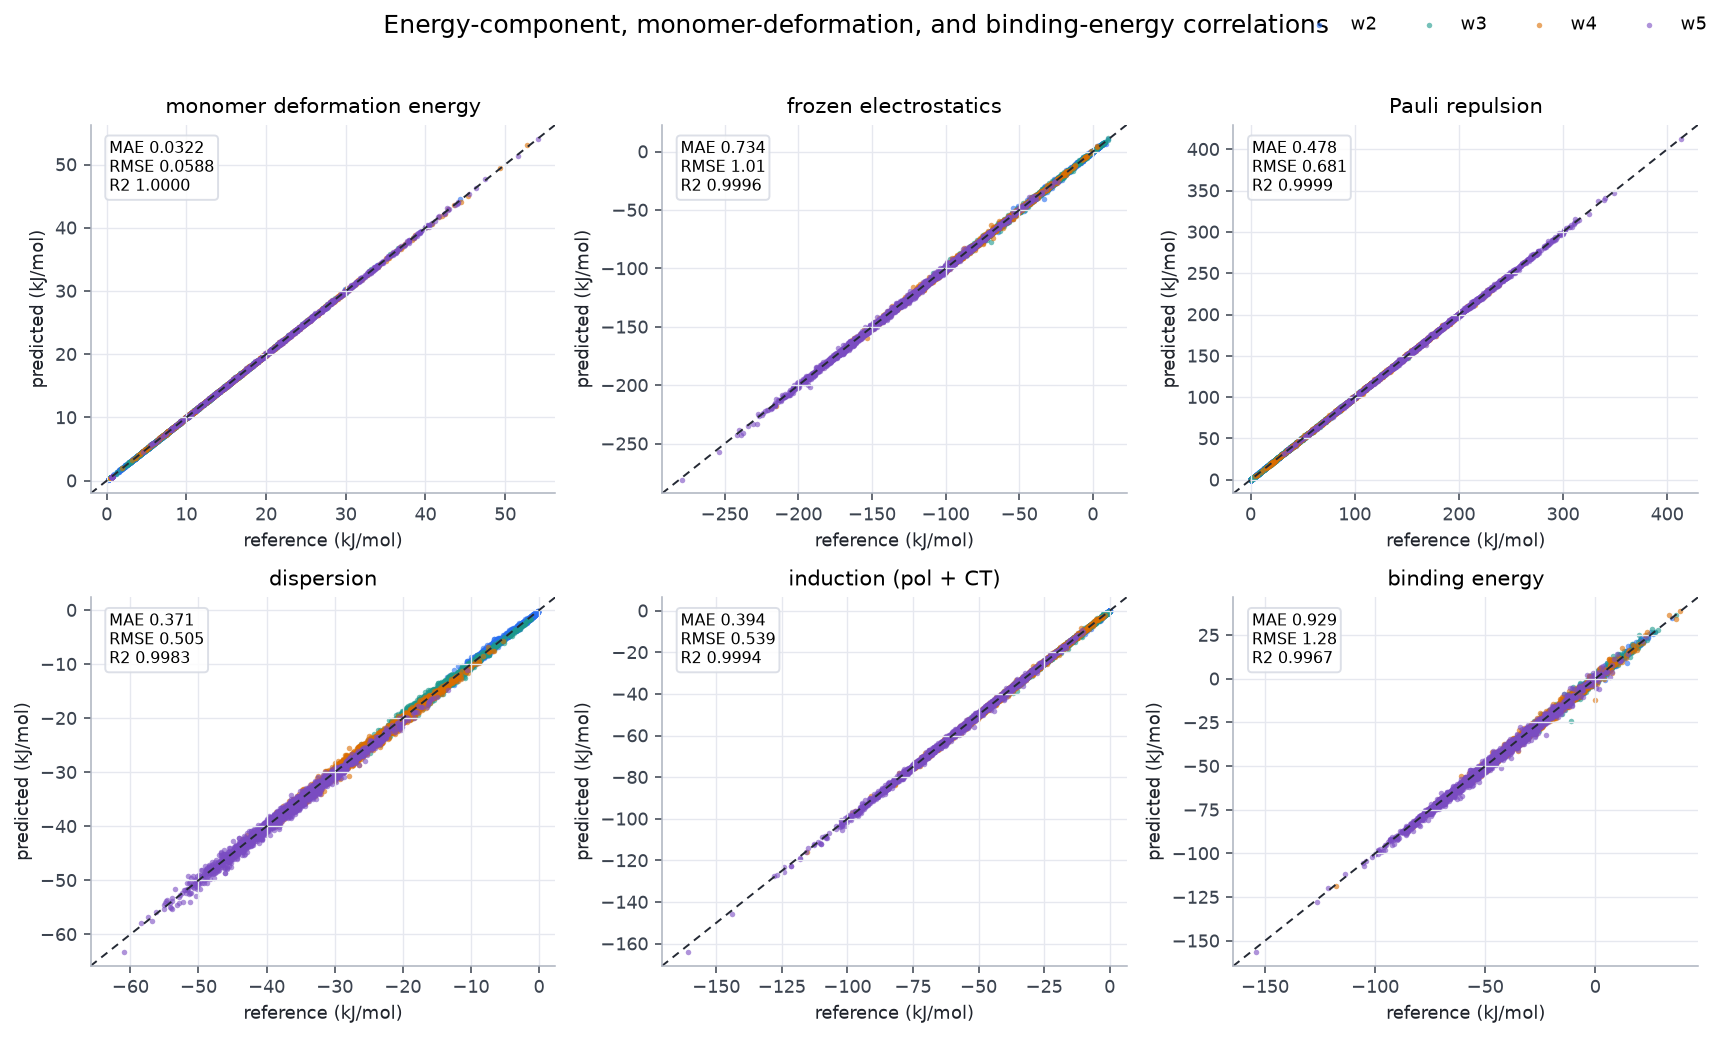

In [24]:
def plot_parity_grid(data, labels, *, title, unit, path=None, ncols=3):
    keys = [k for k, _ in labels if k in data]
    nrows = int(np.ceil(len(keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 3.6 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, key in zip(axes.ravel(), keys):
        ax.set_visible(True)
        d = data[key]
        ref, pred, tags = d["ref"], d["pred"], d.get("tag")
        lo = min(np.min(ref), np.min(pred))
        hi = max(np.max(ref), np.max(pred))
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1.0, ls=(0, (4, 3)))
        if tags is None:
            ax.scatter(ref, pred, s=8, alpha=0.65, lw=0, color="#276ef1")
        else:
            for tag in sorted(set(tags)):
                m = tags == tag
                ax.scatter(ref[m], pred[m], s=8, alpha=0.6, lw=0, color=PALETTE.get(tag, "#555"), label=tag)
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(dict(labels)[key])
        ax.set_xlabel(f"reference ({unit})")
        ax.set_ylabel(f"predicted ({unit})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
    handles, labels_ = axes.ravel()[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_, loc="upper right", frameon=False, ncol=len(handles))
    fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

energy_labels = [(term, label) for term, _target, label in ENERGY_TERMS]
fig = plot_parity_grid(
    energy,
    energy_labels,
    title="Energy-component, monomer-deformation, and binding-energy correlations",
    unit="kJ/mol",
    path=FIGDIR / f"{FIGPREFIX}_energy_correlations.png",
)
plt.show()


## Where the size-dependent offset comes from

The deformation-energy and binding-energy panels above are pooled **per frame**, so a
constant per-*fragment* error is drawn as `n_fragments` times itself: a pure constant looks
like a size-dependent offset. This section separates the two. It reports the one-body
residual per fragment, which is where the constant actually lives, and then replots the two
pooled panels with that single number removed.

Read it as: `bias` is the constant, `MAE - |bias|` is the geometry-dependent part that the
model genuinely gets wrong, and `n_frag * bias` is the offset the pooled plots show.

In the film model the one-body constant lives in the **learnable bonded tables** -- chiefly
the well depth `D`, since `fragment_energy = sum E0 - sum_bonds D + ...` near equilibrium --
so the fit can reach it directly and a residual constant here should be small. If it is not,
compare the `O-H table` line printed at the top against pyCMM: a table that refuses to move
while a constant bias persists means something else is pinning it (`bonded_variance_weight`
only penalizes the *feature-dependent* deviation, never the table).

In [25]:
def onebody_residual_by_fragment(model, datasets, cfg, device, batch_size=BATCH_SIZE):
    """Per-fragment `fragment_energy` residual, kept per fragment rather than per frame.

    `collect_energy_predictions` pools fragments to frames because that is the scale the
    binding energy lives on. That pooling is also what turns a constant into a slope, so this
    deliberately does not do it -- the per-fragment residual is the quantity a constant offset
    is constant in.
    """
    rows = {}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        err, n_frag = [], []
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)
            e = (out.fragment_energy - batch.fragment_energy) * KJMOL_PER_HARTREE
            err.append(to_np(e))
            n_frag.append(to_np(fragments_per_frame(batch)))
        rows[tag] = {"err": np.concatenate(err), "n_frag": np.concatenate(n_frag)}
    return rows


onebody_res = onebody_residual_by_fragment(model, datasets, cfg, device)
pooled = np.concatenate([d["err"] for d in onebody_res.values()])
BIAS = float(pooled.mean())

print("per-fragment one-body residual (kJ/mol)")
print(f"{'cluster':>8}{'n_frag':>8}{'bias':>10}{'MAE':>10}{'std':>10}{'frame offset':>14}")
for tag in sorted(onebody_res):
    d = onebody_res[tag]
    e, nf = d["err"], float(d["n_frag"][0])
    print(f"{tag:>8}{nf:>8.0f}{e.mean():>+10.4f}{np.abs(e).mean():>10.4f}"
          f"{e.std():>10.4f}{nf * e.mean():>+14.4f}")
print(f"\npooled over {len(pooled)} fragments: bias {BIAS:+.4f}  "
      f"MAE {np.abs(pooled).mean():.4f}  std {pooled.std():.4f}")
print(f"with the constant removed:      MAE {np.abs(pooled - BIAS).mean():.4f}  "
      f"RMSE {np.sqrt(((pooled - BIAS) ** 2).mean()):.4f}")


per-fragment one-body residual (kJ/mol)
 cluster  n_frag      bias       MAE       std  frame offset
      w2       2   -0.0023    0.0166    0.0319       -0.0045
      w3       3   -0.0017    0.0161    0.0306       -0.0050
      w4       4   -0.0021    0.0164    0.0306       -0.0082
      w5       5   -0.0027    0.0163    0.0304       -0.0133

pooled over 33522 fragments: bias -0.0022  MAE 0.0163  std 0.0307
with the constant removed:      MAE 0.0172  RMSE 0.0307


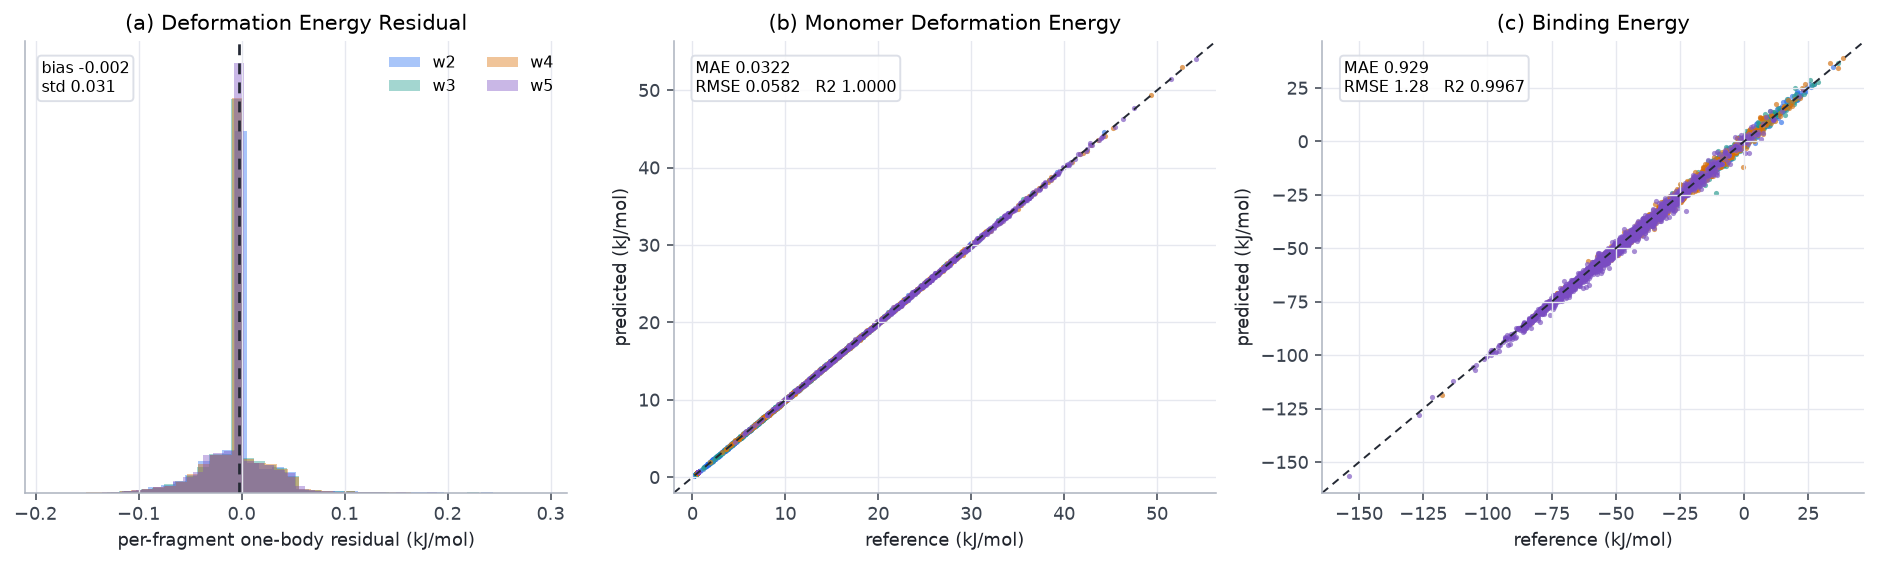

In [40]:
def plot_onebody_offset(onebody_res, energy, bias, path=None):
    """Left: the residual is a constant. Right/centre: the pooled panels with it removed."""
    tags = sorted(onebody_res)
    per_tag_n_frag = {t: float(onebody_res[t]["n_frag"][0]) for t in tags}
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.1))

    ax = axes[0]
    for tag in tags:
        e = onebody_res[tag]["err"]
        ax.hist(e, bins=40, density=True, histtype="stepfilled", alpha=0.4,
                color=PALETTE.get(tag, "#555"), label=tag)
    ax.axvline(bias, color="#242934", lw=1.4, ls=(0, (4, 3)))
    # In axes coordinates, not at the line: the distribution is sharply peaked right where the
    # line falls, so anchoring the label to the data would drop it on top of the spike.
    ax.text(0.03, 0.96, f"bias {bias:+.3f}\nstd {np.concatenate([onebody_res[t]['err'] for t in tags]).std():.3f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
    ax.set_xlabel("per-fragment one-body residual (kJ/mol)")
    ax.set_yticks([])
    ax.set_title("(a) Deformation Energy Residual")
    ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper right")

    # The pooled panels, before and after removing n_frag * bias. `energy` was collected with
    # the same frame ordering, so `n_frag` lines up term by term.
    for ax, term, label in ((axes[1], "onebody", "Monomer Deformation Energy"),
                            (axes[2], "total", "Binding Energy")):
        if term not in energy:
            ax.set_visible(False)
            continue
        d = energy[term]
        ref, pred, tag_arr = d["ref"], d["pred"], d["tag"]
        # Fragment count per frame, looked up by cluster tag rather than by position, so this
        # does not depend on the two collectors having iterated the datasets in the same order.
        n_frag = np.array([per_tag_n_frag[t] for t in tag_arr])
        corrected = pred - n_frag * bias
        lo = min(ref.min(), corrected.min())
        hi = max(ref.max(), corrected.max())
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1.0,
                ls=(0, (4, 3)))
        for tag in tags:
            m = tag_arr == tag
            ax.scatter(ref[m], pred[m], s=7, alpha=0.25, lw=0, color="#b6bcc7")
            ax.scatter(ref[m], corrected[m], s=7, alpha=0.6, lw=0,
                       color=PALETTE.get(tag, "#555"), label=tag)
        mae0, _, _ = metrics(ref, pred)
        mae1, rmse1, r21 = metrics(ref, corrected)
        ax.text(0.04, 0.96,
                f"MAE {mae0:.3g}\n"
                f"RMSE {rmse1:.3g}   R2 {r21:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3",
                      "alpha": 0.85})
        ax.set_xlabel("reference (kJ/mol)")
        ax.set_ylabel("predicted (kJ/mol)")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(f"({'b' if term == 'onebody' else 'c'}) {label}")

    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_onebody_offset(onebody_res, energy, BIAS,
                          path=FIGDIR / f"{FIGPREFIX}_onebody_offset.png")
plt.show()


## Isolated parameters versus the environment

Every channel here is `gate * e_classical`, with no neural term added on top. Each parameter
exists at two values: `theta_0`, generated from the internal feature block alone, and `theta`,
with the environment and cross blocks live. Running a batch twice -- once inside
`environment_off`, which zeroes the env/cross embedders *and* suppresses the bonded-delta gate
-- splits each channel's energy the same way. `iso` is what the model would produce with every
fragment treated as isolated; `env` is what only appears because of what is nearby.

That is the effective many-body content, and it is where it *should* be. `eda_cls_elec` is the
Coulomb interaction between superimposed frozen monomer densities, which is rigorously
pairwise; in the film model its `env` bar is zero **by construction twice over** -- the
permanent multipoles have no environment path at all, and the penetration parameters read
per-element tables. The modified Pauli term and the dispersion are not pairwise, and a
quenched `C6` is what that content looks like here.

**The one-body panel is a live check, not a plot.** `fragment_energy` and the permanent
multipoles must be bitwise identical between the two runs. The cell asserts both.

Induction keeps a third number. Its bonded contribution is `E_bonded(theta) -
E_bonded(theta_0)` -- the Morse/angle parameters re-read in the medium, the learned analogue
of pyCMM's field-dependent Morse -- and it is a route to the label needing no charge to move
and no multipole to relax. In an earlier two-level model the parameter half was 100% of the
`ct` channel while every printed metric looked healthy. It is reported, not penalised: some of
it is real charge transfer, and the size is what says how much.

Everything is normalised **per fragment** so the four cluster sizes are directly comparable.
The one-body bucket gets its own axis because it is two orders of magnitude larger; `E_0`, the
fixed atomic reference, is left out since it is neither fitted nor environment-dependent.

In [27]:
SPLIT_TERMS = [
    ("elst", "frozen\nelectrostatics"),
    ("pauli", "Pauli\nrepulsion"),
    ("disp", "dispersion"),
    ("induction", "induction\n(pol + CT)"),
]
ISO_COLOR = "#3c4450"
ENV_COLOR = "#e07a3f"


def collect_isolated_vs_env(model, datasets, cfg, device, batch_size=BATCH_SIZE):
    """Per-fragment isolated and environment halves of every channel.

    Two forwards per batch: one as trained, one inside `environment_off`. The difference is the
    energy that exists only because of the surroundings.

    The one-body sector is asserted rather than plotted -- `fragment_energy` reads `theta_0`
    and the permanent multipoles read the internal block only, so the two runs must agree
    bitwise on both. If either assertion ever fires, the routing has a leak and every isolated
    number in the notebook is meaningless. The iso run's own `env_shift` is asserted to be an
    exact zero for the same reason: it is what says `environment_off` actually reached every
    parameter family.
    """
    rows = {"tag": []}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)
                with environment_off(model):
                    iso = model(batch)
            n_frag = fragments_per_frame(batch)

            def per_fragment(x):
                return to_np(x / n_frag) * KJMOL_PER_HARTREE

            assert torch.equal(out.fragment_energy, iso.fragment_energy), (
                "fragment_energy moved when the environment was switched off -- the one-body "
                "sector is reading the environment somewhere it must not"
            )
            assert torch.equal(out.parameters.q_perm, iso.parameters.q_perm), (
                "the permanent charges moved when the environment was switched off -- the "
                "permanent/polarization separation has a leak"
            )
            for name, shift in iso.env_shift.items():
                assert float(shift.abs().max()) == 0.0, (
                    f"environment_off left a live env path in {name}; the split below would "
                    f"be measuring the wrong thing"
                )

            for name in out.interaction:
                rows.setdefault(f"{name}|iso", []).append(per_fragment(iso.interaction[name]))
                rows.setdefault(f"{name}|env", []).append(
                    per_fragment(out.interaction[name] - iso.interaction[name])
                )

            # The bonded-parameter half of induction: `E_bonded` at `theta` minus at
            # `theta_0`, exactly the difference the model books into the induction channel.
            if out.energy_bonded_env is not None:
                swap = pool_fragments_to_frames(
                    out.energy_bonded_env - out.energy_bonded, batch
                )
                rows.setdefault("induction|swap", []).append(per_fragment(swap))

            rows.setdefault("onebody|intra", []).append(
                per_fragment(pool_fragments_to_frames(out.energy_intra, batch)))
            rows.setdefault("onebody|bonded", []).append(
                per_fragment(pool_fragments_to_frames(out.energy_bonded, batch)))
            rows["tag"].extend([tag] * batch.n_systems)
    return {k: (np.asarray(v) if k == "tag" else np.concatenate(v)) for k, v in rows.items()}


split = collect_isolated_vs_env(model, datasets, cfg, device)
print(f"{'component':<12}{'isolated':>12}{'environment':>13}{'env share':>11}"
      f"{'bonded half':>13}{'/env':>9}   (kJ/mol per fragment)")
for key, _label in SPLIT_TERMS:
    if f"{key}|iso" not in split:
        continue
    iso, env = split[f"{key}|iso"], split[f"{key}|env"]
    share = np.abs(env).mean() / max(np.abs(iso).mean() + np.abs(env).mean(), 1e-30)
    swap = split.get(f"{key}|swap")
    if swap is None:
        tail = f"{'-':>13}{'-':>9}"
    else:
        frac = np.abs(swap).mean() / max(np.abs(env).mean(), 1e-30)
        tail = f"{swap.mean():>+13.4f}{100 * frac:>8.1f}%"
    print(f"{key:<12}{iso.mean():>+12.4f}{env.mean():>+13.4f}{100 * share:>10.1f}%{tail}")
print(f"\n{'onebody':<12}"
      f"intra classical {split['onebody|intra'].mean():>+8.3f}   "
      f"bonded (Morse + angle) {split['onebody|bonded'].mean():>+10.3f}")
print("environment share of the one-body sector: 0.0% exactly, by construction (asserted above)")


component       isolated  environment  env share  bonded half     /env   (kJ/mol per fragment)
elst            -21.4936      +0.0000       0.0%            -        -
pauli           +27.3188      -0.2428       2.9%            -        -
disp             -5.8738      +0.1473       2.5%            -        -
induction        -2.9817      -5.9267      66.5%      -5.8288    98.3%

onebody     intra classical   +0.403   bonded (Morse + angle)   -962.202
environment share of the one-body sector: 0.0% exactly, by construction (asserted above)


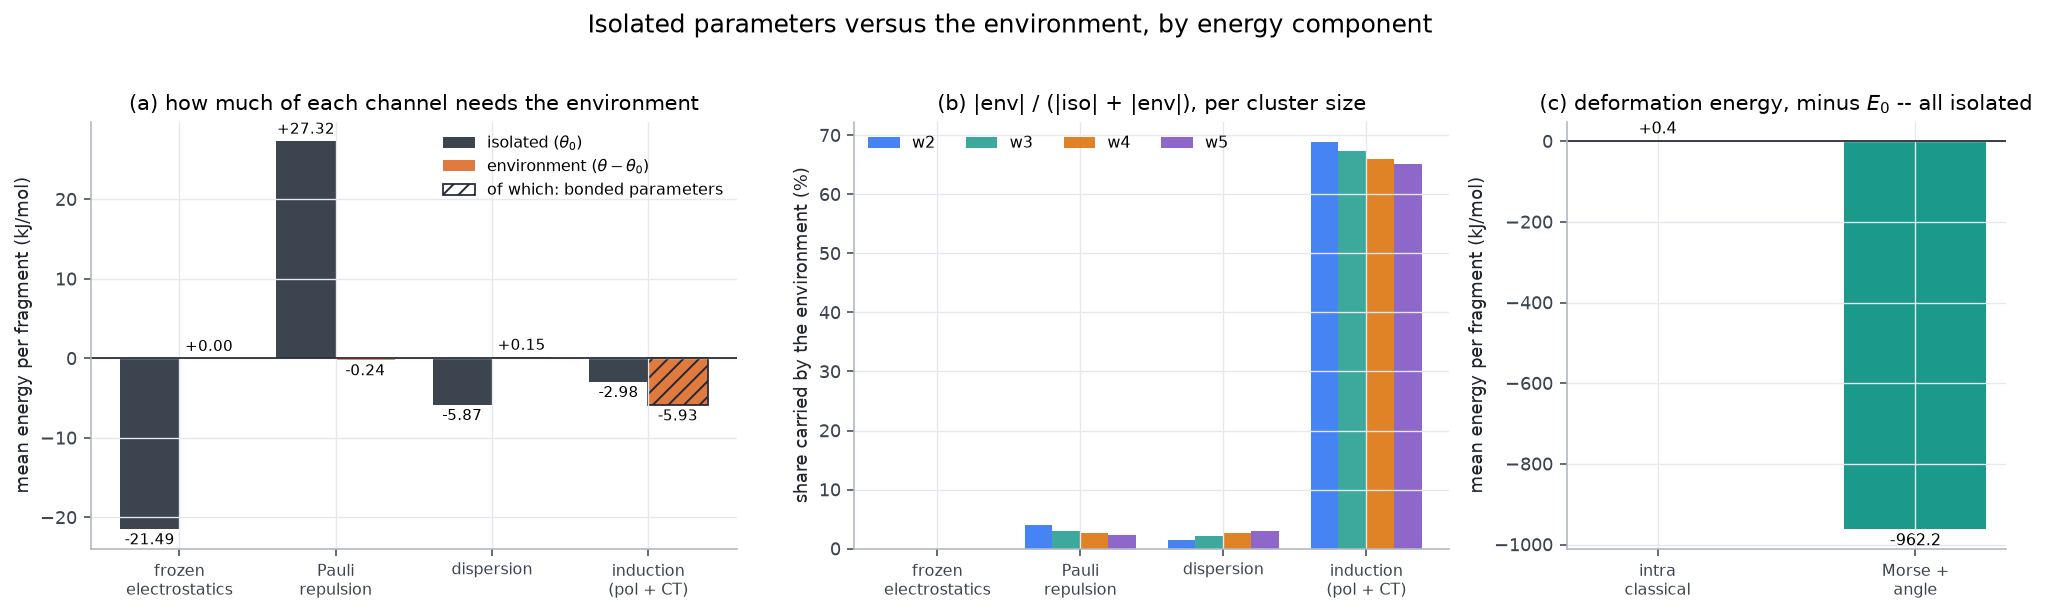

In [28]:
def plot_isolated_vs_env(split, path=None):
    tags = [t for t in ("w2", "w3", "w4", "w5") if t in set(split["tag"])]
    terms = [(k, l) for k, l in SPLIT_TERMS if f"{k}|iso" in split]
    x = np.arange(len(terms))
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2),
                             gridspec_kw={"width_ratios": [1.25, 1.15, 0.85]})

    ax = axes[0]
    width = 0.38
    iso = [split[f"{k}|iso"].mean() for k, _ in terms]
    env = [split[f"{k}|env"].mean() for k, _ in terms]
    ax.bar(x - width / 2, iso, width, color=ISO_COLOR, label=r"isolated ($\theta_0$)")
    ax.bar(x + width / 2, env, width, color=ENV_COLOR, label=r"environment ($\theta-\theta_0$)")
    # Drawn over the environment bar rather than beside it, because it is a *part* of it: the
    # share carried by the bonded parameters rather than by a relaxation of the multipoles.
    swap_drawn = False
    for xi, (k, _label) in enumerate(terms):
        if f"{k}|swap" not in split:
            continue
        ax.bar(xi + width / 2, split[f"{k}|swap"].mean(), width, facecolor="none",
               edgecolor="#242934", hatch="///", lw=0.9,
               label=None if swap_drawn else "of which: bonded parameters")
        swap_drawn = True
    for xi, (a, b) in enumerate(zip(iso, env)):
        for dx, v in ((-width / 2, a), (width / 2, b)):
            ax.annotate(f"{v:+.2f}", (xi + dx, v), ha="center", fontsize=7.5,
                        va="bottom" if v >= 0 else "top",
                        xytext=(0, 2 if v >= 0 else -2), textcoords="offset points")
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([l for _, l in terms], fontsize=8)
    ax.set_ylabel("mean energy per fragment (kJ/mol)")
    ax.set_title("(a) how much of each channel needs the environment")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    width = 0.78 / max(1, len(tags))
    for j, tag in enumerate(tags):
        m = split["tag"] == tag
        share = []
        for k, _ in terms:
            a = np.abs(split[f"{k}|iso"][m]).mean()
            b = np.abs(split[f"{k}|env"][m]).mean()
            share.append(100.0 * b / max(a + b, 1e-30))
        ax.bar(x + (j - (len(tags) - 1) / 2) * width, share, width,
               color=PALETTE.get(tag, "#555"), alpha=0.85, label=tag)
    ax.set_xticks(x)
    ax.set_xticklabels([l for _, l in terms], fontsize=8)
    ax.set_ylabel("share carried by the environment (%)")
    # A share that *grows* with cluster size is the signature of real many-body physics; one
    # that is already large on w2, where there is none, is the environment sector doing
    # two-body work the isolated parameters should be doing.
    ax.set_title("(b) |env| / (|iso| + |env|), per cluster size")
    ax.legend(frameon=False, fontsize=8, ncol=len(tags))

    ax = axes[2]
    pieces = [("onebody|intra", "intra\nclassical", "#7f8794"),
              ("onebody|bonded", "Morse +\nangle", "#1b998b")]
    values = [split[k].mean() for k, _, _ in pieces]
    ax.bar(np.arange(len(pieces)), values, 0.55, color=[c for _, _, c in pieces])
    for i, v in enumerate(values):
        ax.annotate(f"{v:+.1f}", (i, v), ha="center", fontsize=8,
                    va="bottom" if v >= 0 else "top",
                    xytext=(0, 2 if v >= 0 else -2), textcoords="offset points")
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(np.arange(len(pieces)))
    ax.set_xticklabels([l for _, l, _ in pieces], fontsize=8)
    ax.set_ylabel("mean energy per fragment (kJ/mol)")
    # No environment bar here, and that is the point: every term in this panel reads theta_0,
    # and there is no frozen-solve E_internal any more -- the bonded terms carry that energy.
    ax.set_title("(c) deformation energy, minus $E_0$ -- all isolated")

    fig.suptitle("Isolated parameters versus the environment, by energy component",
                 y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_isolated_vs_env(split, path=FIGDIR / f"{FIGPREFIX}_isolated_vs_environment.png")
plt.show()


In [29]:
def collect_response_properties(model, anchor, device, batch_size=BATCH_SIZE):
    if anchor is None:
        raise ValueError("cfg.data.monomer_path is not set, so no polarizability/multipole anchor is available")
    chunks = {
        "polarizability": {"ref": [], "pred": [], "component": []},
        "dipole": {"ref": [], "pred": [], "component": []},
        "quadrupole": {"ref": [], "pred": [], "component": []},
    }
    tri = np.triu_indices(3)
    alpha_labels = np.array(["xx", "xy", "xz", "yy", "yz", "zz"])
    dip_labels = np.array(["x", "y", "z"])
    quad_labels = alpha_labels

    for start in range(0, len(anchor), batch_size):
        batch = anchor.flat_batch(range(start, min(start + batch_size, len(anchor)))).to(device)
        with torch.no_grad():
            # `with_induction=False` is an optimization here, not a correctness need: the
            # film model's isolated-fragment induction is exactly zero by construction (the
            # coupled solve's drive vanishes at the permanent multipoles), so this only skips
            # a solve whose answer is known. `out.charges/mu/quad_s` ARE the permanent
            # multipoles -- there is no frozen solve for them to come off.
            out = model(batch, with_polarizability=True, with_induction=False)
        if out.polarizability is not None and batch.polarizability is not None:
            pred_a = to_np(out.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            ref_a = to_np(batch.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            chunks["polarizability"]["pred"].append(pred_a.ravel())
            chunks["polarizability"]["ref"].append(ref_a.ravel())
            chunks["polarizability"]["component"].extend(np.tile(alpha_labels, pred_a.shape[0]))

        if batch.fragment_dipole is not None and batch.fragment_second_moment is not None:
            quad_c = None if out.quad_s is None else spherical_to_cartesian_quadrupole(out.quad_s)
            frag_q = batch.fragment_charge if batch.fragment_charge is not None else batch.positions.new_zeros(batch.n_fragments)
            pred_d, pred_q = fragment_multipoles(
                out.charges, batch.positions, batch.atomic_numbers, batch.fragment_idx,
                batch.n_fragments, frag_q, out.mu, quad_c,
            )
            ref_d, ref_q = reference_multipoles(
                batch.fragment_dipole, batch.fragment_second_moment, batch.positions,
                batch.atomic_numbers, batch.fragment_idx, batch.n_fragments, frag_q,
            )
            pred_d, ref_d = to_np(pred_d), to_np(ref_d)
            pred_q, ref_q = to_np(pred_q)[:, tri[0], tri[1]], to_np(ref_q)[:, tri[0], tri[1]]
            chunks["dipole"]["pred"].append(pred_d.ravel())
            chunks["dipole"]["ref"].append(ref_d.ravel())
            chunks["dipole"]["component"].extend(np.tile(dip_labels, pred_d.shape[0]))
            chunks["quadrupole"]["pred"].append(pred_q.ravel())
            chunks["quadrupole"]["ref"].append(ref_q.ravel())
            chunks["quadrupole"]["component"].extend(np.tile(quad_labels, pred_q.shape[0]))

    packed = {}
    for key, data in chunks.items():
        if data["pred"]:
            packed[key] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "component": np.asarray(data["component"]),
            }
    return packed


properties = collect_response_properties(model, anchor, device) if anchor is not None else {}
for key, d in properties.items():
    mae, rmse, r2 = metrics(d["ref"], d["pred"])
    print(f"{key:<16} n={len(d['ref']):<6} MAE={mae:.5g} RMSE={rmse:.5g} R2={r2:.5f}")


polarizability   n=2994   MAE=0.073403 RMSE=0.13595 R2=0.99925
dipole           n=1497   MAE=0.009938 RMSE=0.016703 R2=0.99821
quadrupole       n=2994   MAE=0.035641 RMSE=0.054491 R2=0.99926


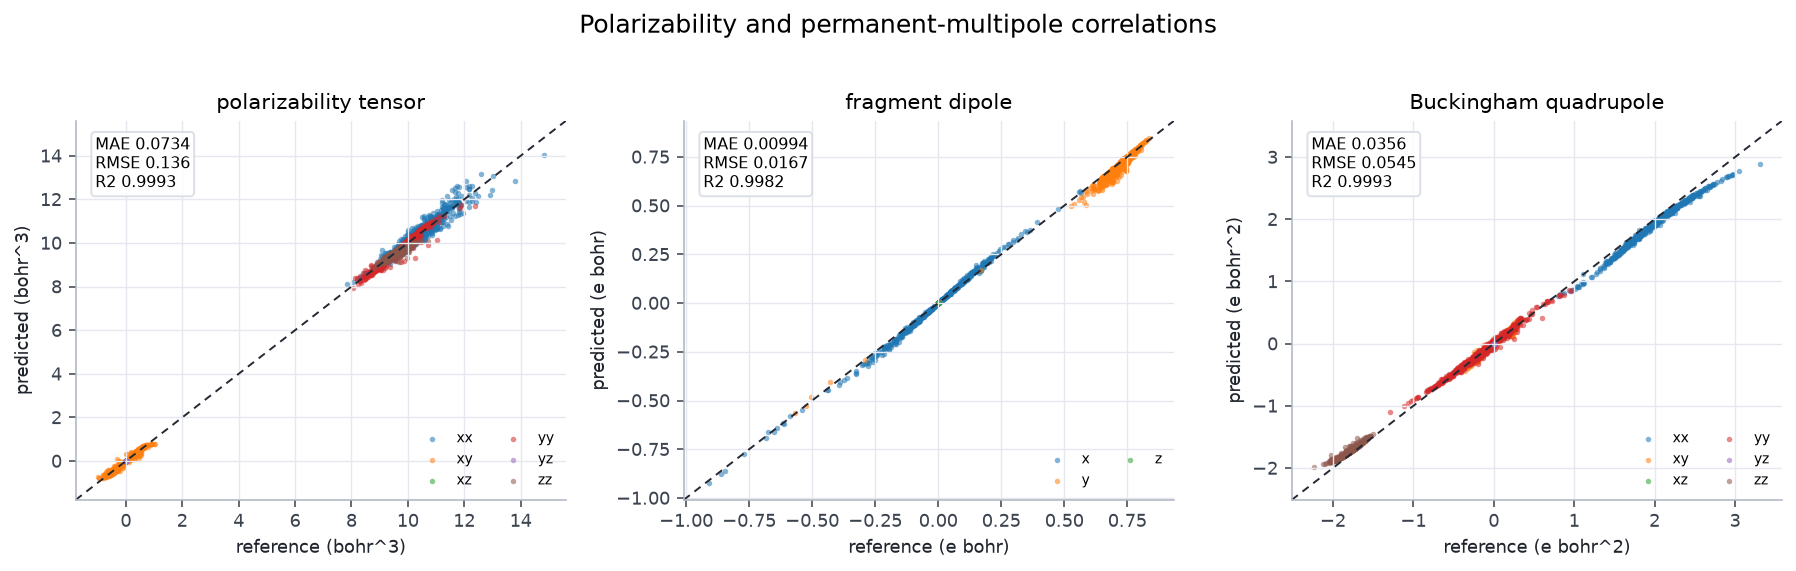

In [30]:
def plot_property_correlations(properties, path=None):
    labels = {
        "polarizability": ("polarizability tensor", "bohr^3"),
        "dipole": ("fragment dipole", "e bohr"),
        "quadrupole": ("Buckingham quadrupole", "e bohr^2"),
    }
    keys = [k for k in labels if k in properties]
    fig, axes = plt.subplots(1, len(keys), figsize=(4.3 * len(keys), 3.9), squeeze=False)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for ax, key in zip(axes.ravel(), keys):
        d = properties[key]
        ref, pred, comp = d["ref"], d["pred"], d["component"]
        lo = min(ref.min(), pred.min())
        hi = max(ref.max(), pred.max())
        pad = 0.05 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
        for i, c in enumerate(sorted(set(comp))):
            m = comp == c
            ax.scatter(ref[m], pred[m], s=8, alpha=0.55, lw=0, color=colors[i % len(colors)], label=c)
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(labels[key][0])
        ax.set_xlabel(f"reference ({labels[key][1]})")
        ax.set_ylabel(f"predicted ({labels[key][1]})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.legend(frameon=False, fontsize=7, ncol=2)
    fig.suptitle("Polarizability and permanent-multipole correlations", y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

if properties:
    fig = plot_property_correlations(properties, path=FIGDIR / f"{FIGPREFIX}_response_property_correlations.png")
    plt.show()


## The generated parameters, at both evaluations

The film forward already carries every parameter at both evaluations (`FilmParameters`), so
nothing here re-runs a head: `theta_0` is the starred field, `theta` the unstarred one, and
their gap is the environment dependence -- the same per-quantity numbers the training log's
`env_*` columns report, here resolved per atom / bond / angle / channel instead of averaged.

What is deliberately **not** plotted, unlike the v4 notebook: the per-element tables. `r0`
(all three channels), the penetration `Z`/`b`, and the damping exponents `b_disp`/`b_pauli`
are element-indexed lookups in this model -- one number per element by design, so a
"distribution" of them is a vertical line and plotting sixteen vertical lines was noise.
Their values print below instead.

What is new, because the model is new:

- **the bonded Morse/angle parameters** `r_eq`, `D`, `k` (and the derived `beta`), `theta_eq`,
  `k_theta` -- per bond/angle, with the pyCMM water constants as reference lines. Their
  `theta - theta_0` gap is the bonded half of induction; their `theta_0` spread around the
  table is what `bonded_variance_weight` disciplines.
- **the response family**: `eta` and the atomic polarizability (isotropic part), now genuinely
  dual-valued -- the environment conditions how a fragment responds, which is where the
  many-body polarization physics lives in this model.
- **the SQE compliance**, per intra-fragment channel, split by endpoint pair (O-H against
  H-H): the learned bond topology of the charge flow.
- the **permanent multipoles** `q`, `|mu|`, `|Theta|` -- single-valued *by architecture* (no
  environment path exists), drawn filled only.

In [31]:
def _bond_kind(z_i, z_j):
    pair = sorted([int(z_i), int(z_j)])
    return "-".join(ELEMENT.get(z, str(z)) for z in pair)


def collect_film_parameters(model, datasets, device, n_frames=PARAMETER_FRAMES_PER_CLUSTER,
                            batch_size=BATCH_SIZE):
    """Every varying generated parameter at both evaluations, straight off the forward.

    Four tables, one per index set: atoms, bonds, angles, SQE channels. Keys with an `_iso`
    twin are dual-valued; the permanent multipoles have no twin because no env-dressed
    evaluation of them exists.
    """
    atoms = {}
    bonds = {}
    angles = {}
    channels = {}

    def push(store, **kv):
        for k, v in kv.items():
            store.setdefault(k, []).append(v)

    for tag, ds in datasets.items():
        take = min(n_frames, len(ds))
        for start in range(0, take, batch_size):
            batch = ds.flat_batch(range(start, min(start + batch_size, take))).to(device)
            with torch.no_grad():
                out = model(batch)
            p = out.parameters
            z = to_np(batch.atomic_numbers)

            def iso_trace(alpha):
                return to_np(torch.diagonal(alpha, dim1=-2, dim2=-1).mean(-1))

            push(
                atoms,
                tag=np.repeat(tag, len(z)), Z=z,
                q_perm=to_np(p.q_perm),
                mu_perm=to_np(p.mu_perm.norm(dim=-1)),
                quad_perm=to_np(p.quad_perm.norm(dim=-1)),
                eta=to_np(p.response.eta), eta_iso=to_np(p.response0.eta),
                alpha_iso_part=iso_trace(p.response.alpha),
                alpha_iso_part_iso=iso_trace(p.response0.alpha),
                c6=to_np(p.disp[0]), c6_iso=to_np(p.disp0[0]),
                q_pauli=to_np(p.pauli[0]), q_pauli_iso=to_np(p.pauli0[0]),
                mu_pauli=to_np(p.pauli[2].norm(dim=-1)),
                mu_pauli_iso=to_np(p.pauli0[2].norm(dim=-1)),
                quad_pauli=to_np(p.pauli[3].norm(dim=-1)),
                quad_pauli_iso=to_np(p.pauli0[3].norm(dim=-1)),
                a_env=to_np(out.a_env), gate=to_np(p.gate),
                env_norm=to_np(out.env_norm),
            )

            topo = out.topology
            def beta(b):
                return to_np(torch.sqrt(b.k / (2.0 * b.d)))
            push(
                bonds,
                tag=np.repeat(tag, topo.bond_index.shape[1]),
                kind=np.array([
                    _bond_kind(z[i], z[j])
                    for i, j in zip(*[to_np(t) for t in topo.bond_index])
                ]),
                r_eq=to_np(p.bonded.r_eq) * BOHR_ANG,
                r_eq_iso=to_np(p.bonded0.r_eq) * BOHR_ANG,
                d=to_np(p.bonded.d), d_iso=to_np(p.bonded0.d),
                k=to_np(p.bonded.k), k_iso=to_np(p.bonded0.k),
                beta=beta(p.bonded), beta_iso=beta(p.bonded0),
            )
            push(
                angles,
                tag=np.repeat(tag, topo.angle_index.shape[1]),
                theta_eq=np.degrees(to_np(p.bonded.cos_theta_eq.clamp(-1, 1).arccos())),
                theta_eq_iso=np.degrees(to_np(p.bonded0.cos_theta_eq.clamp(-1, 1).arccos())),
                k_theta=to_np(p.bonded.k_theta), k_theta_iso=to_np(p.bonded0.k_theta),
            )

            # The compliance rows align with the model's own channel graph: the complete
            # intra-fragment enumeration (union_channels at cutoff 0 *is* this list).
            ch, _ = intra_fragment_channels(batch.fragment_idx)
            push(
                channels,
                tag=np.repeat(tag, ch.shape[1]),
                kind=np.array([
                    _bond_kind(z[i], z[j]) for i, j in zip(*[to_np(t) for t in ch])
                ]),
                s=to_np(p.response.compliance),
                s_iso=to_np(p.response0.compliance),
            )

    pack = lambda d: {k: np.concatenate(v) for k, v in d.items()}
    return pack(atoms), pack(bonds), pack(angles), pack(channels)


atoms, bonds, angles, channels = collect_film_parameters(model, datasets, device)
print(f"parameter rows: {len(atoms['Z'])} atoms, {len(bonds['r_eq'])} bonds, "
      f"{len(angles['theta_eq'])} angles, {len(channels['s'])} channels")

# The static per-element tables, printed rather than plotted: one number each by design.
species_z = sorted(int(z) for z in state["neighbor_types"])   # species index order
species_idx = torch.arange(len(species_z))
r0_all, alpha_all = model.range_heads(torch.zeros(len(species_z), 0), species_idx)
def _per_element(table):
    return ", ".join(f"{ELEMENT.get(z, z)} {float(table[i]):.3f}"
                     for i, z in enumerate(species_z))
print("\nstatic per-element tables (not plotted):")
for name in r0_all:
    print(f"  r0_{name:<6} {_per_element(r0_all[name])}  A    "
          f"alpha {float(alpha_all[name]):.1f} 1/A")
rh = model.network.response_heads
print(f"  {'Z_pen':<9} {_per_element((rh.log_z_prior + rh.d_log_z).exp())}")
print(f"  {'b_pen':<9} {_per_element((rh.log_b_prior + rh.d_log_b).exp())}")

print(f"\n{'parameter':<12}{'index':>8}{'theta_0':>12}{'theta':>12}{'mean |shift|':>14}")
for store, key, idx in ((atoms, "eta", "atom"), (atoms, "c6", "atom"),
                        (atoms, "q_pauli", "atom"), (bonds, "r_eq", "bond"),
                        (bonds, "d", "bond"), (bonds, "k", "bond"),
                        (angles, "k_theta", "angle"), (channels, "s", "channel")):
    a, b = store[f"{key}_iso"], store[key]
    print(f"{key:<12}{idx:>8}{a.mean():>12.4g}{b.mean():>12.4g}{np.abs(b - a).mean():>14.5g}")


parameter rows: 5040 atoms, 3360 bonds, 1680 angles, 5040 channels

static per-element tables (not plotted):
  r0_elst   H 1.582, O 0.958  A    alpha 36.3 1/A
  r0_pauli  H 1.553, O 0.963  A    alpha 36.3 1/A
  r0_disp   H 1.544, O 0.916  A    alpha 36.2 1/A
  Z_pen     H 0.950, O 3.592
  b_pen     H 2.243, O 2.180

parameter      index     theta_0       theta  mean |shift|
eta             atom      0.2232       0.174      0.051003
c6              atom       13.06       12.52       0.67188
q_pauli         atom         2.5       2.474      0.027069
r_eq            bond      0.9665      0.9691     0.0026419
d               bond      0.1836      0.1848     0.0011669
k               bond      0.5201      0.5278       0.01017
k_theta        angle      0.1638      0.1633    0.00087018
s            channel      0.5743        0.66      0.088551


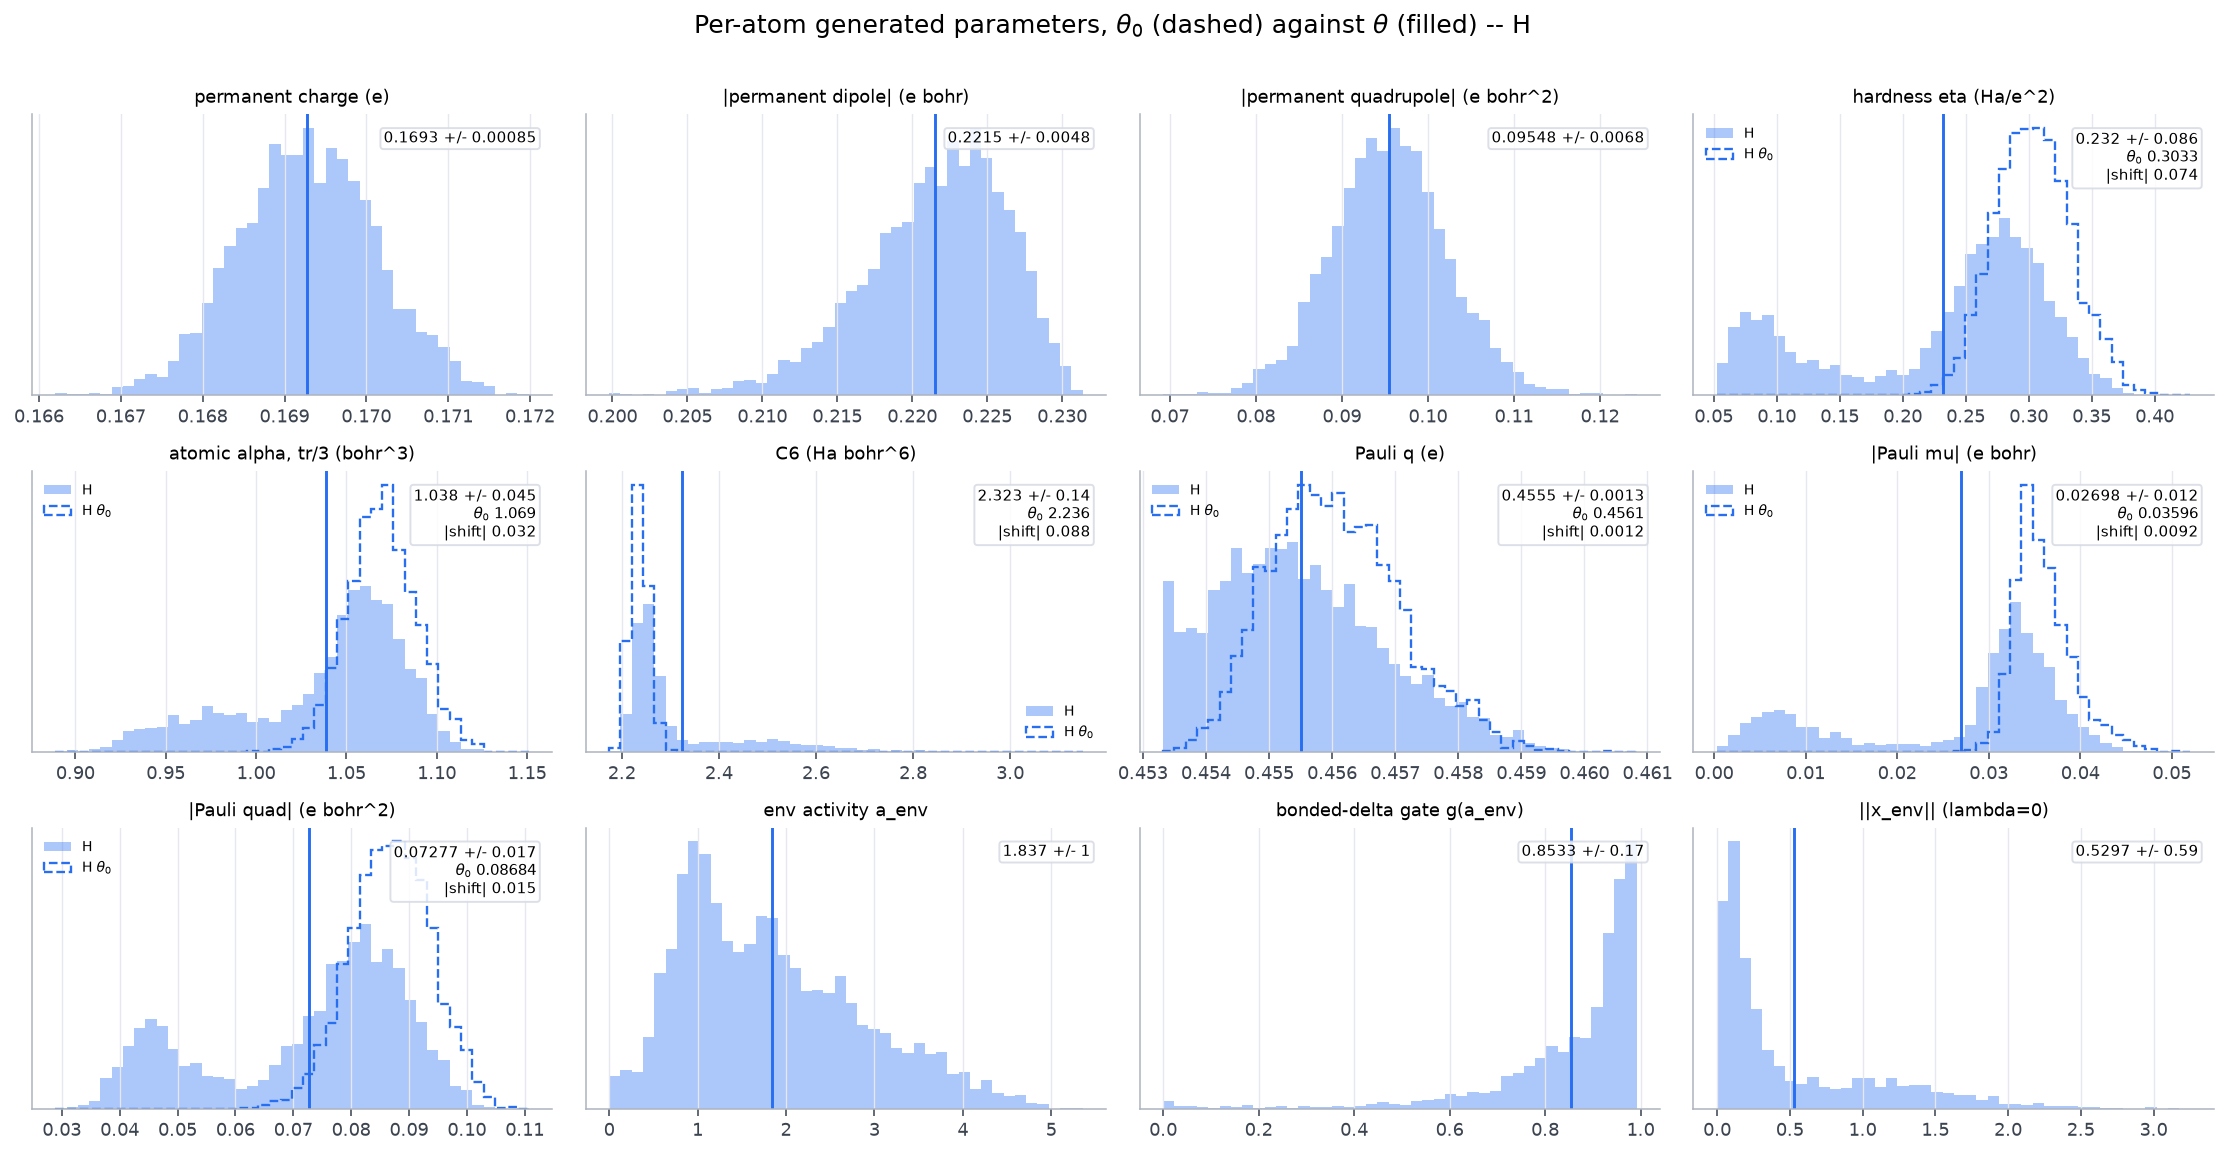

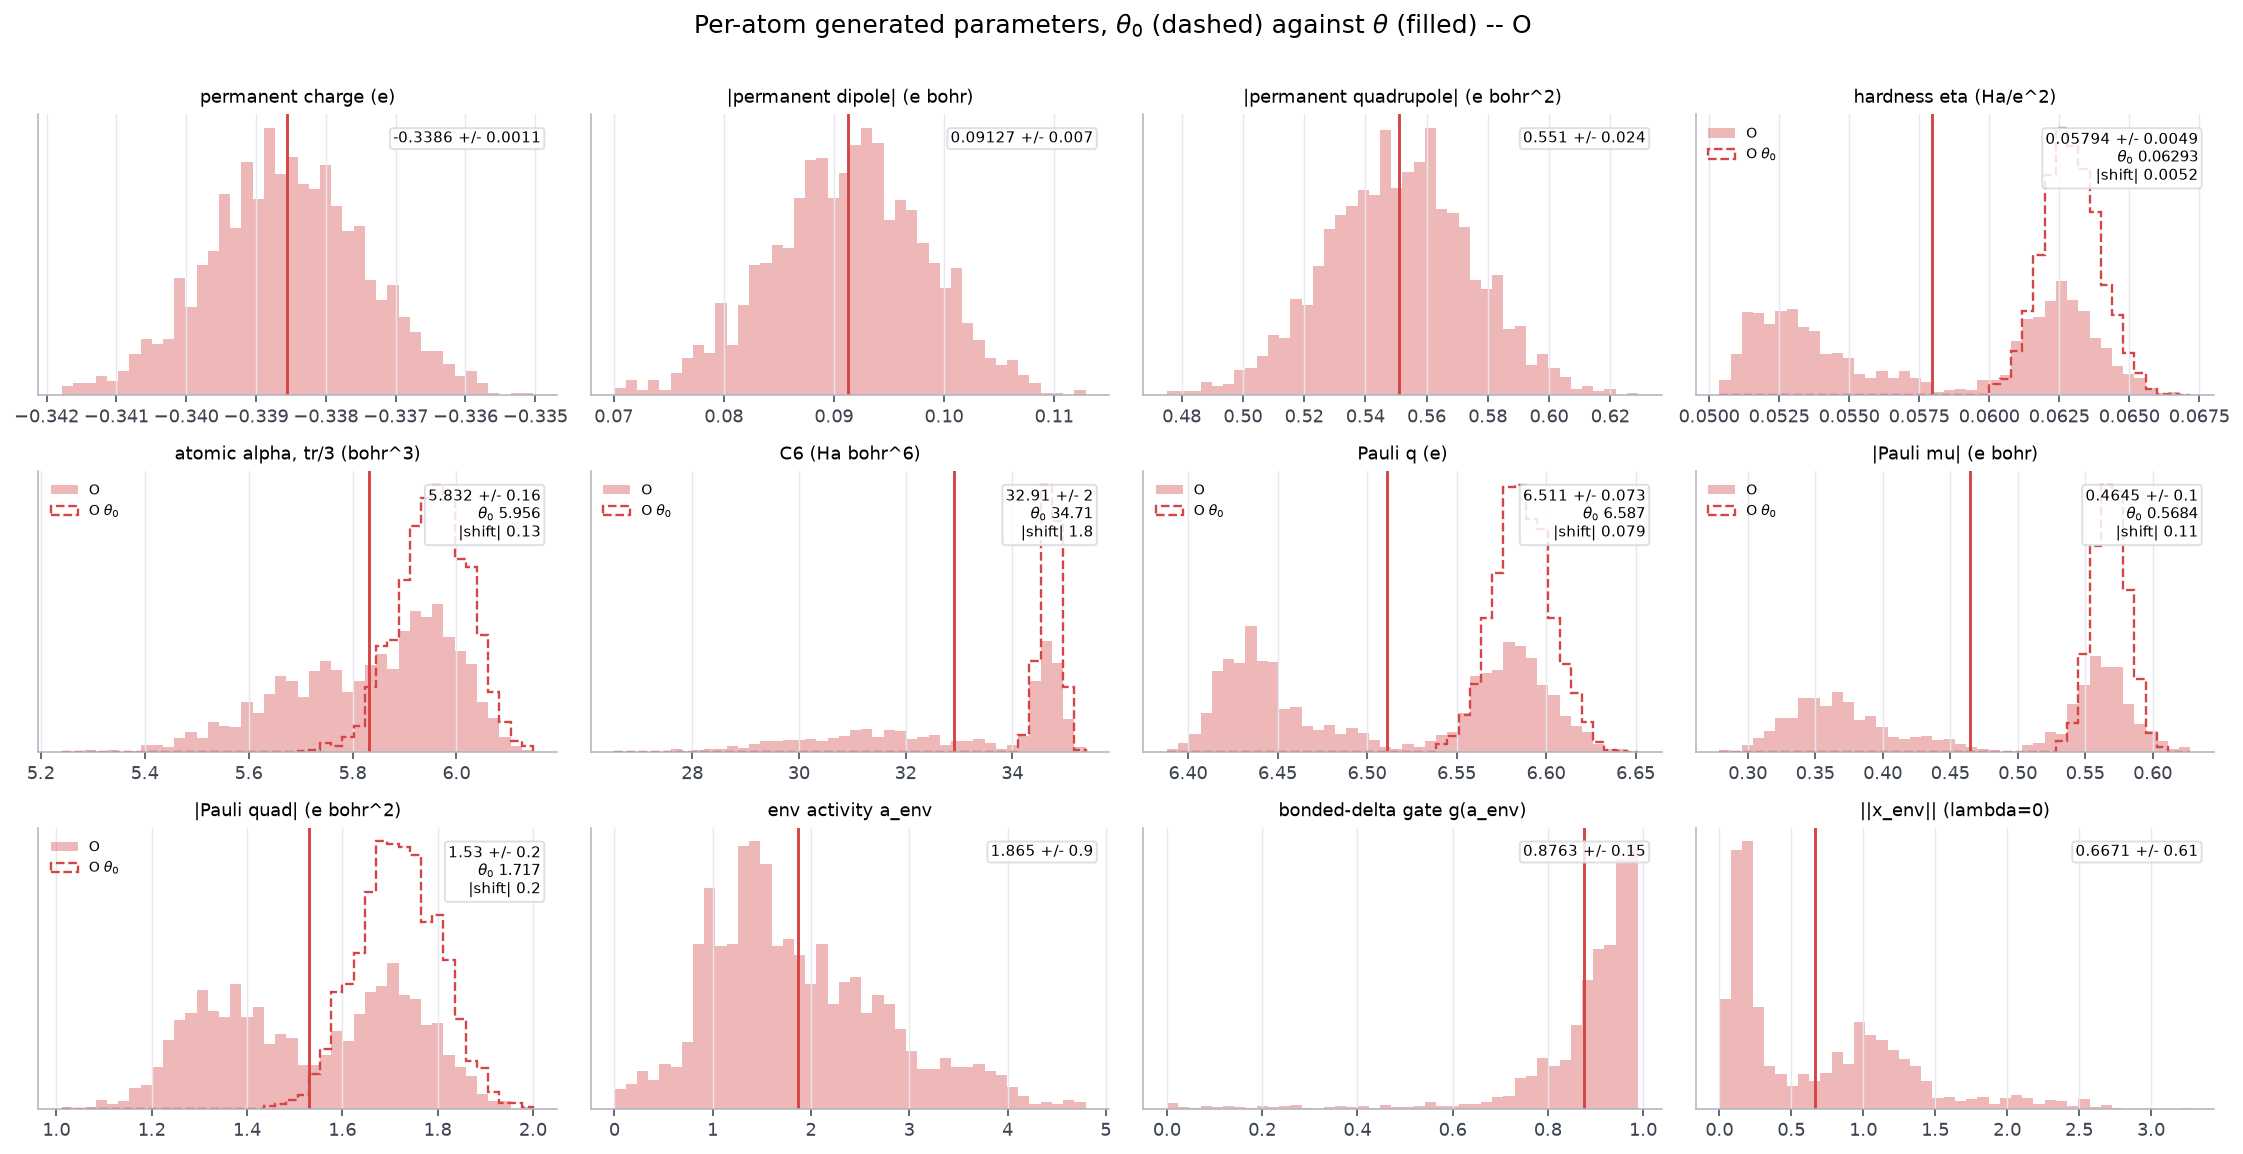

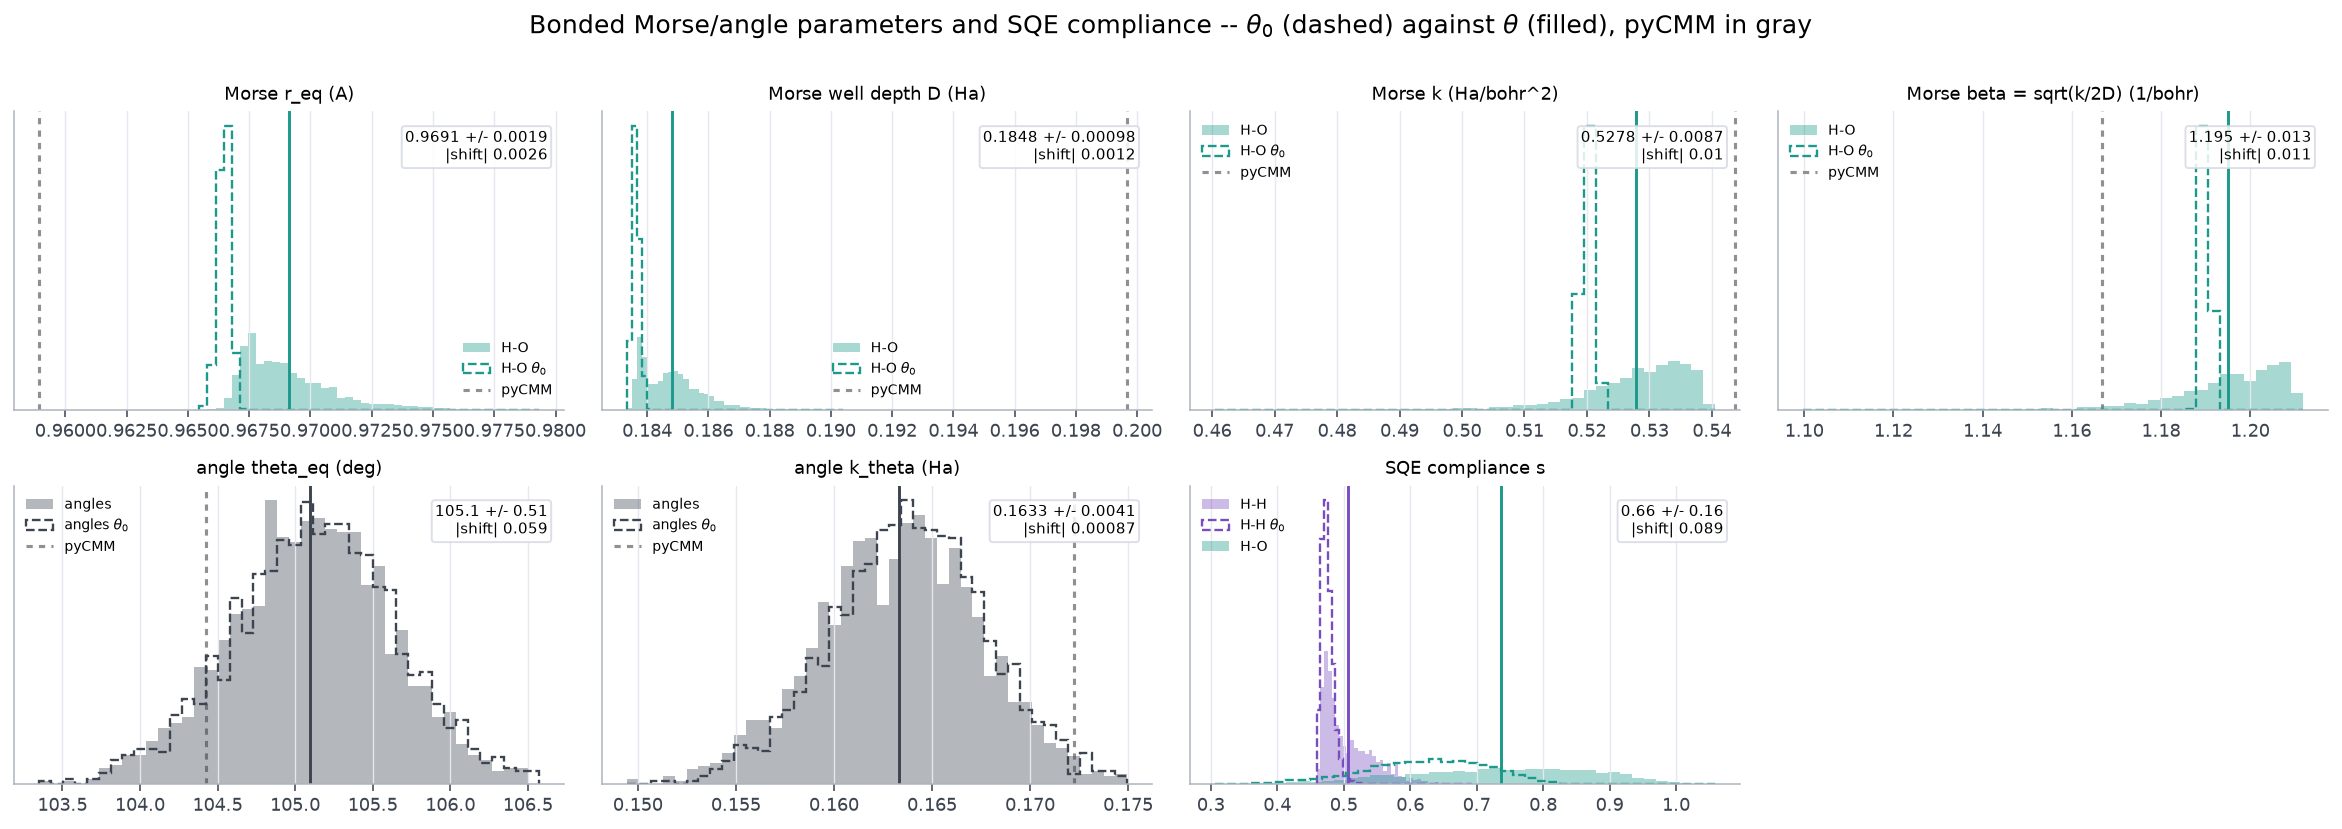

In [32]:
#: pyCMM water constants for the reference lines, in the units each panel plots.
_R_EQ, _D, _K = DEFAULT_BOND_PRIOR[(1, 8)]
_THETA, _KTHETA = DEFAULT_ANGLE_PRIOR[8]
PYCMM_LINES = {
    "r_eq": _R_EQ * BOHR_ANG, "d": _D, "k": _K,
    "beta": float(np.sqrt(_K / (2 * _D))),
    "theta_eq": float(np.degrees(_THETA)), "k_theta": _KTHETA,
}

#: (key, label, dual?) for the per-atom figure, one figure per element.
ATOM_SPECS = [
    ("q_perm", "permanent charge (e)", False),
    ("mu_perm", "|permanent dipole| (e bohr)", False),
    ("quad_perm", "|permanent quadrupole| (e bohr^2)", False),
    ("eta", "hardness eta (Ha/e^2)", True),
    ("alpha_iso_part", "atomic alpha, tr/3 (bohr^3)", True),
    ("c6", "C6 (Ha bohr^6)", True),
    ("q_pauli", "Pauli q (e)", True),
    ("mu_pauli", "|Pauli mu| (e bohr)", True),
    ("quad_pauli", "|Pauli quad| (e bohr^2)", True),
    ("a_env", "env activity a_env", False),
    ("gate", "bonded-delta gate g(a_env)", False),
    ("env_norm", "||x_env|| (lambda=0)", False),
]

#: (store-name, key, label) for the bonded/compliance figure; every entry is dual.
BONDED_SPECS = [
    ("bonds", "r_eq", "Morse r_eq (A)"),
    ("bonds", "d", "Morse well depth D (Ha)"),
    ("bonds", "k", "Morse k (Ha/bohr^2)"),
    ("bonds", "beta", "Morse beta = sqrt(k/2D) (1/bohr)"),
    ("angles", "theta_eq", "angle theta_eq (deg)"),
    ("angles", "k_theta", "angle k_theta (Ha)"),
    ("channels", "s", "SQE compliance s"),
]


def _dual_hist(ax, vals, iso_vals, color, name, first):
    """theta filled, theta_0 dashed outline, both on shared bins; means as vlines."""
    lo = min(vals.min(), iso_vals.min())
    hi = max(vals.max(), iso_vals.max())
    if hi - lo <= 1e-12:
        ax.axvline(float(vals[0]), color=color, lw=2.0, label=name)
        ax.set_xlim(lo - max(abs(lo) * 0.05, 1e-3), hi + max(abs(hi) * 0.05, 1e-3))
        return
    bins = np.linspace(lo, hi, 43)
    ax.hist(vals, bins=bins, density=True, histtype="stepfilled", alpha=0.38,
            color=color, label=name)
    ax.axvline(vals.mean(), color=color, lw=1.5)
    if not np.allclose(iso_vals, vals):
        ax.hist(iso_vals, bins=bins, density=True, histtype="step", color=color,
                lw=1.2, ls="--", label=f"{name} $\\theta_0$" if first else None)


def plot_atom_parameters(atoms, z, path=None, ncols=4):
    """One panel per per-atom parameter, one figure per element.

    Split by element because the two are not on the same scale: C6 is ~2 on H and ~37 on O,
    so a shared axis draws H as a spike at the origin and hides its whole distribution.
    """
    mask = atoms["Z"] == z
    color = ELEMENT_COLOR.get(int(z), "#555")
    name = ELEMENT.get(int(z), str(z))
    nrows = int(np.ceil(len(ATOM_SPECS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.7 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, (key, label, dual) in zip(axes.ravel(), ATOM_SPECS):
        ax.set_visible(True)
        vals = atoms[key][mask]
        iso_vals = atoms[f"{key}_iso"][mask] if dual else vals
        _dual_hist(ax, vals, iso_vals, color, name, first=True)
        summary = f"{vals.mean():.4g} +/- {vals.std():.2g}"
        if dual and not np.allclose(iso_vals, vals):
            summary += f"\n$\\theta_0$ {iso_vals.mean():.4g}\n|shift| {np.abs(vals - iso_vals).mean():.2g}"
        ax.text(0.97, 0.94, summary, transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
                bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(label, fontsize=9)
        ax.set_yticks([])
        if dual and ax.get_legend_handles_labels()[1]:
            ax.legend(frameon=False, fontsize=7)
    fig.suptitle(
        f"Per-atom generated parameters, $\\theta_0$ (dashed) against $\\theta$ (filled) -- {name}",
        y=1.01, fontsize=13,
    )
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


def plot_bonded_parameters(bonds, angles, channels, path=None, ncols=4):
    """The Morse/angle parameters and the SQE compliance, with pyCMM reference lines.

    These are the parameters the film model generates *instead of* a neural bond energy, and
    the figure is the readout of both design dials at once: the spread of each dashed
    (theta_0) distribution around its gray pyCMM line is what `bonded_variance_weight`
    disciplines, and the dashed-to-filled gap is the environment dependence that feeds the
    induction channel. Compliance is split by endpoint pair -- the O-H channels are the
    covalent topology, and how far the H-H channels sit below them is the learned bond graph.
    """
    stores = {"bonds": bonds, "angles": angles, "channels": channels}
    nrows = int(np.ceil(len(BONDED_SPECS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.9 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    kind_colors = {"H-O": "#1b998b", "H-H": "#7a4cc2", "O-O": "#db6d00"}
    for ax, (store_name, key, label) in zip(axes.ravel(), BONDED_SPECS):
        ax.set_visible(True)
        store = stores[store_name]
        kinds = sorted(set(store["kind"])) if "kind" in store else [None]
        for ki, kind in enumerate(kinds):
            m = np.ones(len(store[key]), bool) if kind is None else (store["kind"] == kind)
            if not m.any():
                continue
            color = kind_colors.get(kind, "#3c4450")
            _dual_hist(ax, store[key][m], store[f"{key}_iso"][m], color,
                       kind or store_name, first=ki == 0)
        if key in PYCMM_LINES:
            ax.axvline(PYCMM_LINES[key], color="#909090", lw=1.6, ls=(0, (2, 2)),
                       label="pyCMM", zorder=0)
        vals = store[key]
        iso_vals = store[f"{key}_iso"]
        summary = (f"{vals.mean():.4g} +/- {vals.std():.2g}\n"
                   f"|shift| {np.abs(vals - iso_vals).mean():.2g}")
        ax.text(0.97, 0.94, summary, transform=ax.transAxes, ha="right", va="top",
                fontsize=7.5,
                bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(label, fontsize=9)
        ax.set_yticks([])
        if ax.get_legend_handles_labels()[1]:
            ax.legend(frameon=False, fontsize=7)
    fig.suptitle(
        "Bonded Morse/angle parameters and SQE compliance -- "
        "$\\theta_0$ (dashed) against $\\theta$ (filled), pyCMM in gray",
        y=1.01, fontsize=13,
    )
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


for z in sorted(set(atoms["Z"])):
    name = ELEMENT.get(int(z), str(int(z)))
    fig = plot_atom_parameters(
        atoms, z=int(z),
        path=FIGDIR / f"{FIGPREFIX}_parameter_distributions_{name}.png",
    )
    plt.show()

fig = plot_bonded_parameters(
    bonds, angles, channels,
    path=FIGDIR / f"{FIGPREFIX}_bonded_parameter_distributions.png",
)
plt.show()


In [33]:
class EnergyTermModel(torch.nn.Module):
    def __init__(self, model, term):
        super().__init__()
        self.model = model
        self.term = term

    def forward(self, batch):
        out = self.model(batch)
        if self.term == "total":
            # For the MBE plot, the total binding contribution beyond pairwise is the
            # interaction sum. One-body deformation cancels only if singleton terms are
            # included; this helper's convention is E(singleton) = 0.
            energy = out.energy.new_zeros(out.energy.shape)
            for value in out.interaction.values():
                energy = energy + value
        elif self.term == "onebody":
            energy = pool_fragments_to_frames(out.fragment_energy, batch)
        else:
            energy = out.interaction[self.term]
        return SimpleNamespace(energy=energy)


def strongest_indices(dataset, n, key=MBE_SORT_KEY):
    batch = dataset.flat_batch(range(len(dataset)))
    if batch.eda is not None and key in batch.eda:
        values = to_np(batch.eda[key])
    else:
        values = to_np(batch.energy)
    return np.argsort(values)[:min(n, len(values))].tolist()


def collect_many_body_by_term(model, datasets, terms=None, per_cluster=MBE_PER_CLUSTER):
    if terms is None:
        terms = ["elst", "pauli", "disp"]
        if model.induction:
            terms.append("induction")
        terms.append("total")
    rows = []
    for term in terms:
        if term != "total" and term not in model.classical and term not in ("induction", "onebody"):
            continue
        wrapped = EnergyTermModel(model, term).to(next(model.parameters()).device)
        for tag in [t for t in ("w3", "w4", "w5") if t in datasets]:
            ds = datasets[tag]
            idx = strongest_indices(ds, per_cluster)
            res = mbe_dataset(wrapped, ds, idx, split_components=False, progress_every=0)
            k = KJMOL_PER_HARTREE
            for i in range(len(idx)):
                row = {
                    "term": term,
                    "tag": tag,
                    "n_fragments": int(res.n_fragments[i]),
                    "total": float(res.total[i]) * k,
                    "two_body": float(res.two_body[i]) * k,
                    "many_body": float(res.many_body[i]) * k,
                }
                for order in (3, 4, 5):
                    vals = res.by_order.get(order)
                    row[f"e{order}"] = float(vals[i]) * k if vals is not None else 0.0
                rows.append(row)
    return rows


mbe_rows = collect_many_body_by_term(model, datasets)
print(f"many-body rows: {len(mbe_rows)}")
for term in sorted({r['term'] for r in mbe_rows}):
    vals = np.array([r["many_body"] for r in mbe_rows if r["term"] == term])
    print(f"{term:<8} mean={vals.mean():>9.4f} kJ/mol   mean abs={np.abs(vals).mean():>9.4f}")


many-body rows: 600
disp     mean=   0.5179 kJ/mol   mean abs=   0.5179
elst     mean=   0.0000 kJ/mol   mean abs=   0.0000
induction mean= -12.4676 kJ/mol   mean abs=  12.4676
pauli    mean=  -0.7615 kJ/mol   mean abs=   0.7666
total    mean= -12.7112 kJ/mol   mean abs=  12.7112


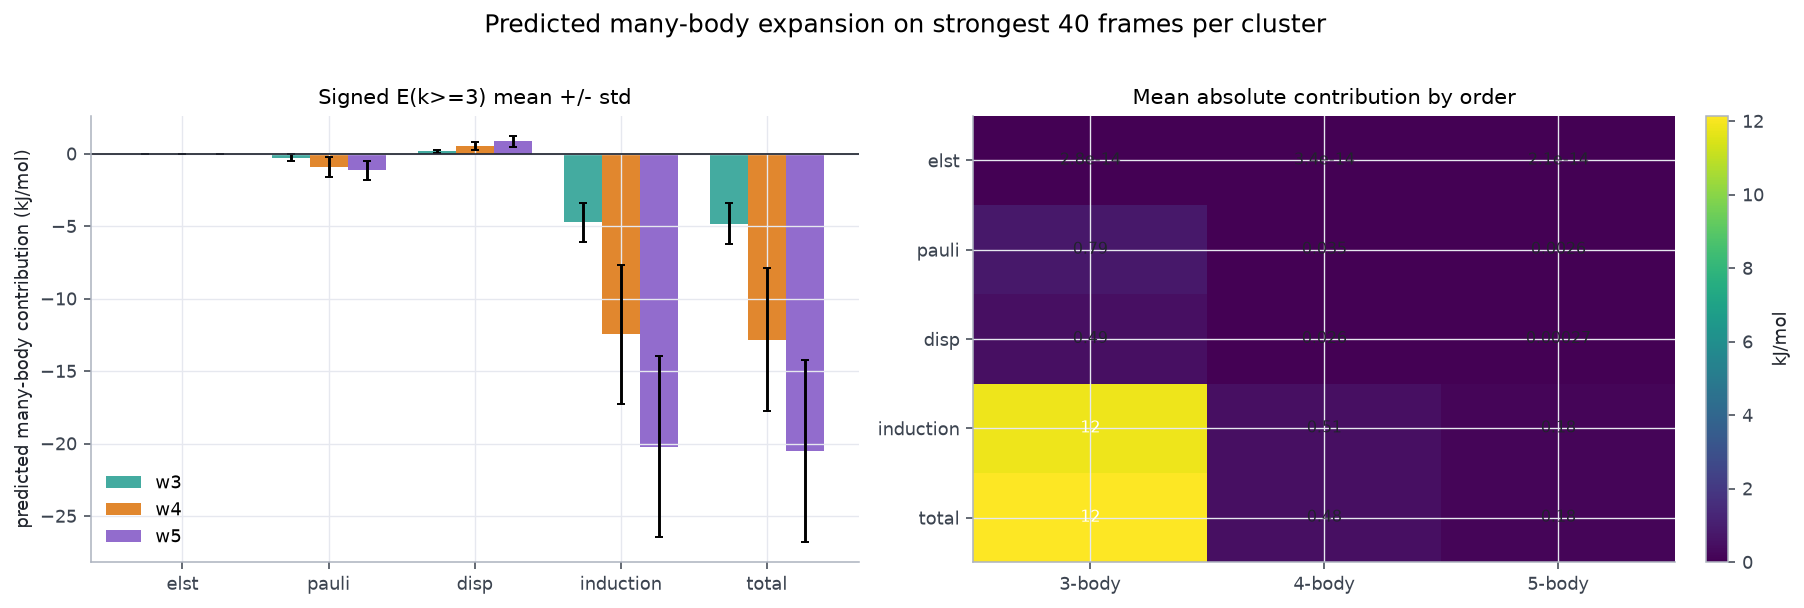

In [34]:
def plot_many_body(rows, path=None):
    terms = [t for t in ["elst", "pauli", "disp", "induction", "total"] if any(r["term"] == t for r in rows)]
    tags = [t for t in ["w3", "w4", "w5"] if any(r["tag"] == t for r in rows)]
    x = np.arange(len(terms))
    width = 0.78 / max(1, len(tags))
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.2))

    ax = axes[0]
    for j, tag in enumerate(tags):
        means, stds = [], []
        for term in terms:
            vals = np.array([r["many_body"] for r in rows if r["term"] == term and r["tag"] == tag])
            means.append(np.mean(vals) if len(vals) else 0.0)
            stds.append(np.std(vals) if len(vals) else 0.0)
        ax.bar(x + (j - (len(tags) - 1) / 2) * width, means, width=width,
               yerr=stds, capsize=2, color=PALETTE.get(tag, "#555"), alpha=0.82, label=tag)
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(terms)
    ax.set_ylabel("predicted many-body contribution (kJ/mol)")
    ax.set_title("Signed E(k>=3) mean +/- std")
    ax.legend(frameon=False)

    ax = axes[1]
    orders = ["e3", "e4", "e5"]
    image = np.zeros((len(terms), len(orders)))
    for i, term in enumerate(terms):
        for j, order in enumerate(orders):
            vals = np.array([r[order] for r in rows if r["term"] == term])
            image[i, j] = np.mean(np.abs(vals)) if len(vals) else 0.0
    im = ax.imshow(image, aspect="auto", cmap="viridis")
    ax.set_yticks(np.arange(len(terms)))
    ax.set_yticklabels(terms)
    ax.set_xticks(np.arange(len(orders)))
    ax.set_xticklabels(["3-body", "4-body", "5-body"])
    ax.set_title("Mean absolute contribution by order")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("kJ/mol")
    for i in range(len(terms)):
        for j in range(len(orders)):
            ax.text(j, i, f"{image[i, j]:.2g}", ha="center", va="center",
                    color="white" if image[i, j] > image.max() * 0.45 else "#20242c", fontsize=8)

    fig.suptitle(f"Predicted many-body expansion on strongest {MBE_PER_CLUSTER} frames per cluster", y=1.02, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_many_body(mbe_rows, path=FIGDIR / f"{FIGPREFIX}_many_body_by_term.png")
plt.show()


In [35]:
def collect_force_predictions(model, datasets, cfg, device, n_frames=FORCE_FRAMES_PER_CLUSTER):
    ref_parts, pred_parts, tags = [], [], []
    for tag, ds in datasets.items():
        if not ds.has_forces:
            print(f"{tag}: no force labels; skipping")
            continue
        indices = frame_indices(ds, cfg)[:min(n_frames, len(ds))]
        for idx in indices:
            batch = ds.flat_batch([idx]).to(device)
            batch.positions.requires_grad_(True)
            out = model(batch)
            forces = compute_forces(out.energy, batch.positions, create_graph=False)
            ref = to_np(batch.forces) * KJMOL_PER_HARTREE
            pred = to_np(forces) * KJMOL_PER_HARTREE
            ref_parts.append(ref.reshape(-1))
            pred_parts.append(pred.reshape(-1))
            tags.extend([tag] * ref.size)
    return {
        "ref": np.concatenate(ref_parts),
        "pred": np.concatenate(pred_parts),
        "tag": np.asarray(tags),
    }


forces = collect_force_predictions(model, datasets, cfg, device)
mae, rmse, r2 = metrics(forces["ref"], forces["pred"])
print(f"force components: n={len(forces['ref'])}  MAE={mae:.5g}  RMSE={rmse:.5g}  R2={r2:.5f}  unit=kJ/mol/A")


force components: n=5040  MAE=3.0481  RMSE=4.3184  R2=0.99687  unit=kJ/mol/A


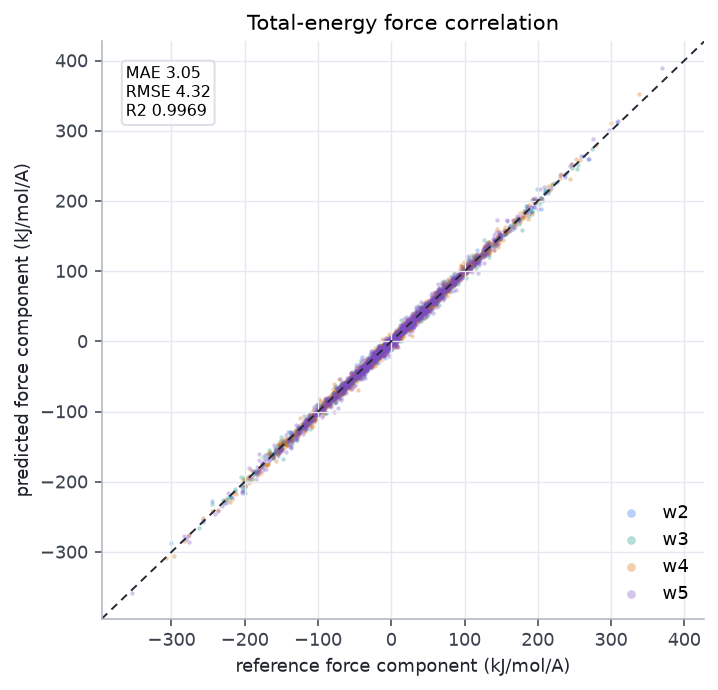

In [36]:
def plot_force_correlation(forces, path=None):
    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    ref, pred, tags = forces["ref"], forces["pred"], forces["tag"]
    lo = min(ref.min(), pred.min())
    hi = max(ref.max(), pred.max())
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
    for tag in sorted(set(tags)):
        m = tags == tag
        ax.scatter(ref[m], pred[m], s=5, alpha=0.32, lw=0, color=PALETTE.get(tag, "#555"), label=tag)
    mae, rmse, r2 = metrics(ref, pred)
    ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
    ax.set_xlabel("reference force component (kJ/mol/A)")
    ax.set_ylabel("predicted force component (kJ/mol/A)")
    ax.set_title("Total-energy force correlation")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.legend(frameon=False, markerscale=2)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_force_correlation(forces, path=FIGDIR / f"{FIGPREFIX}_force_correlation.png")
plt.show()


## Notes

- To regenerate these diagnostics for a different model, edit `CHECKPOINT` at the top. The
  model is rebuilt from the config the checkpoint carries, so there is no stage to select and
  no way for the notebook to build something other than what the weights came from. Figure
  names follow the checkpoint directory, so two runs do not overwrite each other.
- **`environment_off` needs two switches in this model** -- zeroing the env/cross embedders
  makes the joined trunk latent equal the isolated one, and suppressing the gate kills the
  bonded delta branch, which reads the (now identical) latent through its own zero-init head
  times `g(a_env)`. The split cell asserts the iso run's `env_shift` is an exact zero, so a
  future env path that both switches miss fails loudly rather than skewing the bars.
- `elst` must show `env = 0`, and in the film model this is doubly structural: the permanent
  multipoles have no environment columns anywhere, and the penetration parameters are
  per-element tables. Pauli and dispersion should not be zero; that is their many-body
  content. Read panel (b) for how the share behaves with cluster size -- growth from w2 to w5
  is real many-body physics; a share already large on w2 means the environment sector is doing
  two-body work that belongs in `theta_0`, and `film.env_penalty_weight` is the dial.
- `induction` is one channel fitted against `eda_pol + eda_ct`. Its `bonded half` column is
  `E_bonded(theta) - E_bonded(theta_0)`: the part carried by the Morse/angle parameters
  shifting in the medium rather than by the coupled solve relaxing the multipoles. Both are
  physical -- the environment-dependence of bonding *is* the charge-transfer mechanism here,
  and pyCMM implements the same physics as its field-dependent Morse -- but if it is most of
  `env` while the solve contributes nothing, induction has become a network wearing the label.
  Two earlier charge-transfer channels failed exactly that way.
- The bonded-parameter figure is the film design's own readout. Three things to check on it:
  the dashed `theta_0` distributions should be *narrow* around their means (that is
  `bonded_variance_weight` working -- wide means the Morse "parameters" are absorbing PES
  error as a disguised pair energy); their means may sit off the gray pyCMM lines (the
  learnable tables moved, which is fine and printed at the top); and the dashed-to-filled gap
  should be small on w2-dominated distributions and grow with coordination.
- The compliance panel splits by endpoint pair. The O-H channels are the covalent charge-flow
  topology; the H-H channels sitting well below them is the model recovering the covalent
  graph from the complete intra-fragment enumeration, the `s -> 0` closure the SQE
  parameterization is built around.
- Monomer deformation and cluster binding energies use `REFERENCE_SPECIES` from
  `ISOLATED_SPECIES_REFERENCE` as the zero of energy. The same constant is subtracted from the
  reference and the prediction, so it shifts both axes and not the residuals.
